In [28]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 25
day = 24

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

25 24
optimal travel lag is 8.058058058058059 cm based on kde of travel at max spatial information
optimal travel lag is 8.058058058058059 cm
there are 43 non_grid and non_spatial_cells
there are 22 grid_cells
there are 38 non grid spatial cells
there are 5 non spatial cells
there are 0 speed cells
there are 65 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'PAR' 'VISpl2/3']
for the grid cells the unique locations are ['ENTm1' 'PAR']
unique brain regions ['ENTm1' 'PAR' 'VISpl2/3']
there are 38 MEC cells
there are 29 PARA cells
there are 0 PRE cells
there are 2 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 69 all cells
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 31.047640039475038
Not merging labels 0 and 2 with distance 22.591503661418038
Not merging labels 0 and 3 with distance 16.49742982040

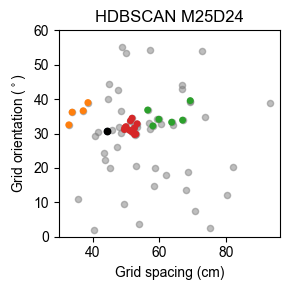

for module 0, there are 4 cells with average spacing 35.587350997051466
for module 1, there are 6 cells with average spacing 62.37350875674008
for module 2, there are 11 cells with average spacing 51.48593593297482
25 24
for module 0, there are 4 cells
for module 2, there are 11 cells
for module 1, there are 6 cells
plotting vr rate maps using cluster_ids [146, 147, 152, 153, 160, 162, 172, 181, 182, 204, 240]
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225


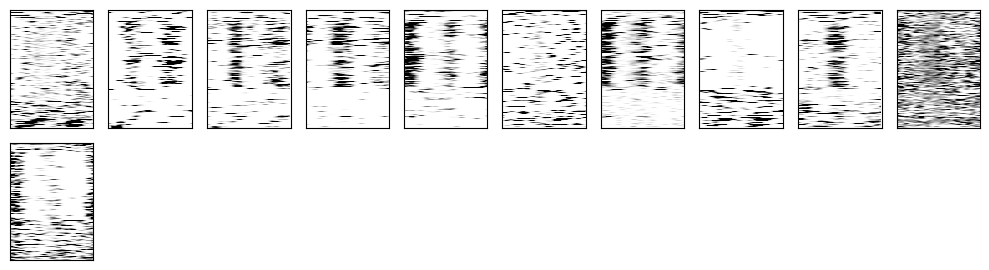

plotting vr rate maps using cluster_ids [112, 124, 128, 130, 135, 149]
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225


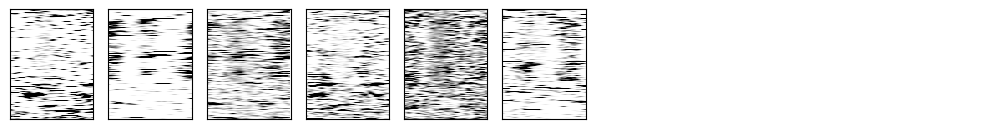

plotting vr rate maps using cluster_ids [236, 243, 244, 257]
n trials: 225
n trials: 225
n trials: 225
n trials: 225


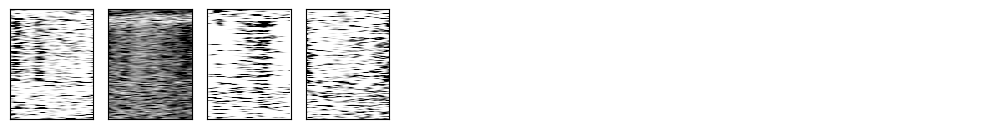

plotting vr rate maps using cluster_ids [113, 115, 117, 119, 120, 122, 125, 133, 144, 148, 151, 155, 159, 161, 165, 167, 169, 170, 174, 180, 187, 190, 194, 196, 206, 207, 210, 216, 231, 246, 247, 249, 253, 255, 258, 265, 267, 280]
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225


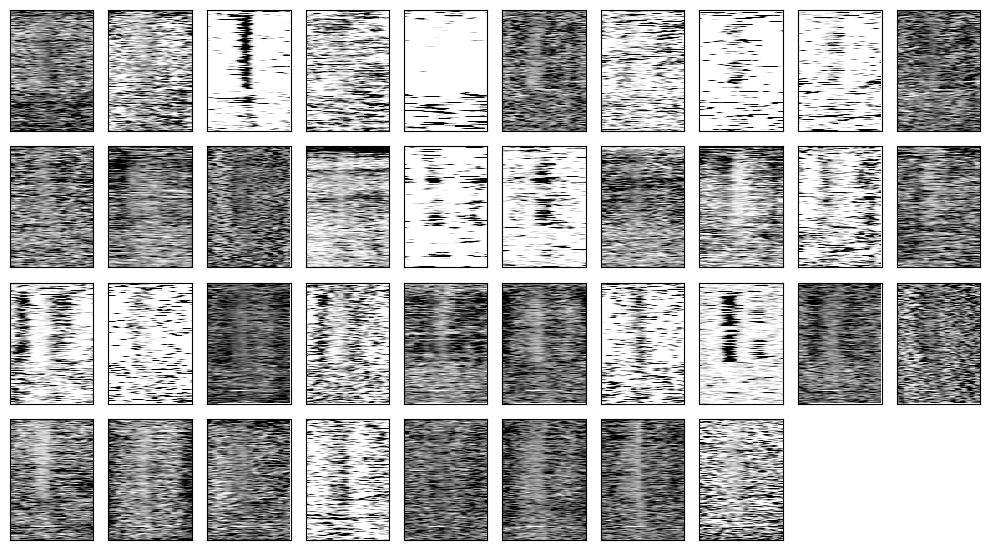

plotting vr rate maps using cluster_ids [97, 102, 192, 245, 293]
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225


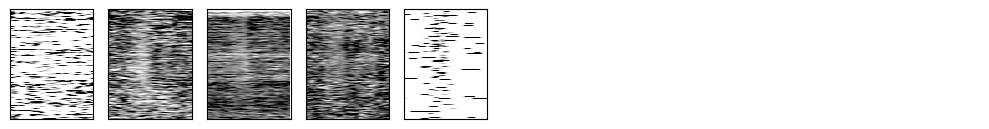

plotting vr rate maps using cluster_ids [112, 124, 128, 130, 135, 146, 147, 149, 152, 153, 160, 162, 172, 181, 182, 204, 224, 236, 240, 243, 244, 257]
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225
n trials: 225


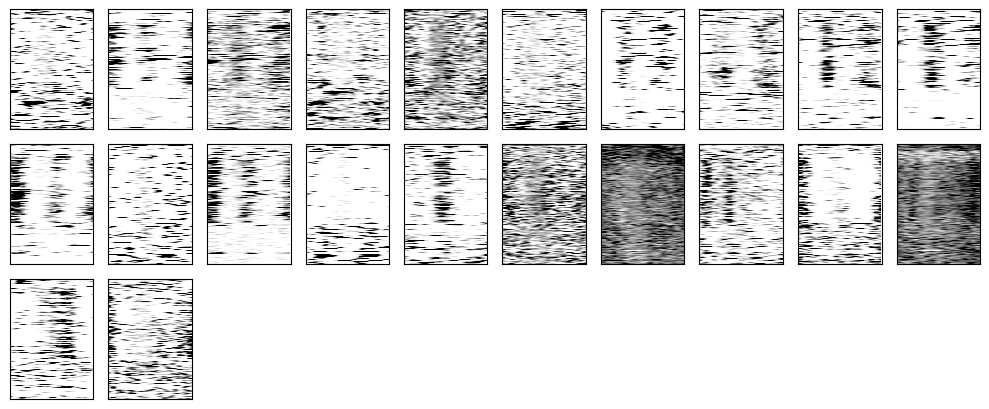

plotting vr rate maps using cluster_ids []


In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)

g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)


In [33]:
print(g_m_cluster_ids[0])

[146, 147, 152, 153, 160, 162, 172, 181, 182, 204, 240]


In [32]:
print(ngs.cluster_id.values.tolist())

[113, 115, 117, 119, 120, 122, 125, 133, 144, 148, 151, 155, 159, 161, 165, 167, 169, 170, 174, 180, 187, 190, 194, 196, 206, 207, 210, 216, 231, 246, 247, 249, 253, 255, 258, 265, 267, 280]


In [4]:
Mouse = f'M{mouse}'
data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
clusters_df = clusters_df[clusters_df['mouse'] == mouse]
shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
clusters_df = reconstruct_shank_id(clusters_df, mouse)
probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)

ymin = -300; ymax = 3000
xmin = -200; xmax = 1000
xs = np.arange(xmin, xmax, 1)
ys = np.arange(ymin, ymax, 1)

annotations = np.zeros((len(ys), len(xs)), dtype=object)
for yi, y in enumerate(ys):
    for xi, x in enumerate(xs):
        coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
        # use the CCF coordinates, get an index and look up the annotation in the brainrender allen_brain_10um volume
        z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
        annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
        if len(structure_set[structure_set['id'] == annotation_index]) ==1:
            annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
        else:
            annotation ='root' # out of brain
        annotations[yi,xi] = annotation
annotation_colors = get_annotation_colors_2D(annotations)

hi


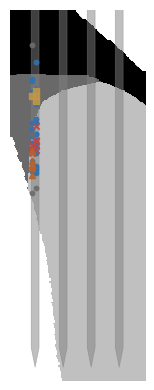

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
unique_colors = np.unique(annotation_colors)
for color in unique_colors:
    border_points = extract_border(annotation_colors, color, only_border=False)
    x_points = xs[border_points[:, 1]]
    y_points = ys[border_points[:, 0]]
    ax.scatter(x_points, y_points, color=color, s=1, label=color, rasterized=True)
plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
               probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
# plot cell locations 
ax.scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="#3171ae", alpha=0.9, s=10)
ax.scatter(ns.probe_x.values, ns.probe_y.values, marker='o', color="#6c6c6c", alpha=0.9, s=10)

markers = ['x','^', 's']
colors=["#c04744", "#B6632F", "#c09744"]
for i, cluster_ids in enumerate(g_m_cluster_ids):
    gc_m = gcs[np.isin(gcs.cluster_id, cluster_ids)]
    ax.scatter(gc_m.probe_x.values, gc_m.probe_y.values, marker=markers[i], color=colors[i], alpha=0.9, s=20)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_probe_brainrender.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()

In [6]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)

last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

# compute the spectrogram and labels from the most adunant grid module
peak_indices = [12, 28, 44, 60, 76]
cluster_ids = g_m_cluster_ids[0]
tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
results = spectral_analysis(tcs_to_use, tl, bs=bs)
spectrograms = results[3] 
fvalid = results[5]
S = spectrograms.mean(0)
max_peaks = np.argmax(S, axis=0)
labels = np.isin(max_peaks, peak_indices).astype(int)

# compute trial labels for task anchoring to use in the xgboost model mask
tc = tcs[172] # example grid cell
tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
tc = tc[:last_ephys_bin] # only want bins with ephys data in it
trial_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring

Identified 1 candidate modules


plot a grid cell

In [7]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

In [8]:
test_grid_cell_id = 172  # the grid cell we will use to test the model
predictor_co_modular_grid_cell_id = 187  # a co modular grid cell
predictor_non_co_modular_grid_cell_id = 236 # a non co modular grid cell
predictor_non_co_modular_grid_cell_id2 = 128 # another non co modular grid cell
predictor_ngs_cell_id = 174  # a non grid spatial cell

print(f'Grid cell id: {test_grid_cell_id}')
print(f'Co-modular grid cell id: {predictor_co_modular_grid_cell_id}')
print(f'Non co-modular grid cell id: {predictor_non_co_modular_grid_cell_id}')
print(f'Non co-modular grid cell id2: {predictor_non_co_modular_grid_cell_id2}')
print(f'Non grid spatial cell id: {predictor_ngs_cell_id}') 

Grid cell id: 172
Co-modular grid cell id: 187
Non co-modular grid cell id: 236
Non co-modular grid cell id2: 128
Non grid spatial cell id: 174


plot a reference grid cell
n trials: 225


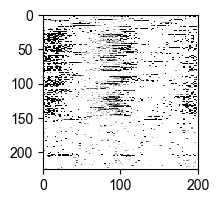

plot a co modular grid cell
n trials: 225


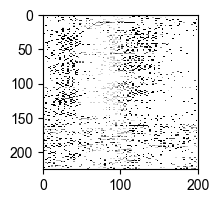

plot a non co modular grid cell
n trials: 225


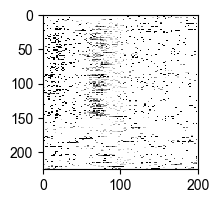

plot another non co modular grid cell
n trials: 225


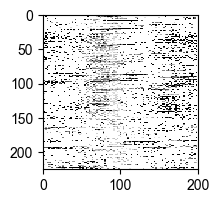

plot a ngs cell
n trials: 225


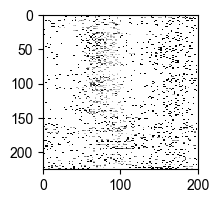

In [9]:
print('plot a reference grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[test_grid_cell_id]), bs=bs, tl=tl, p=95)
plt.show()
print('plot a co modular grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_co_modular_grid_cell_id]), bs=bs, tl=tl, p=95)
plt.show()

print('plot a non co modular grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_non_co_modular_grid_cell_id]), bs=bs, tl=tl, p=95)
plt.show()

print('plot another non co modular grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_non_co_modular_grid_cell_id2]), bs=bs, tl=tl, p=95)
plt.show()

print('plot a ngs cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_ngs_cell_id]), bs=bs, tl=tl, p=95)
plt.show()

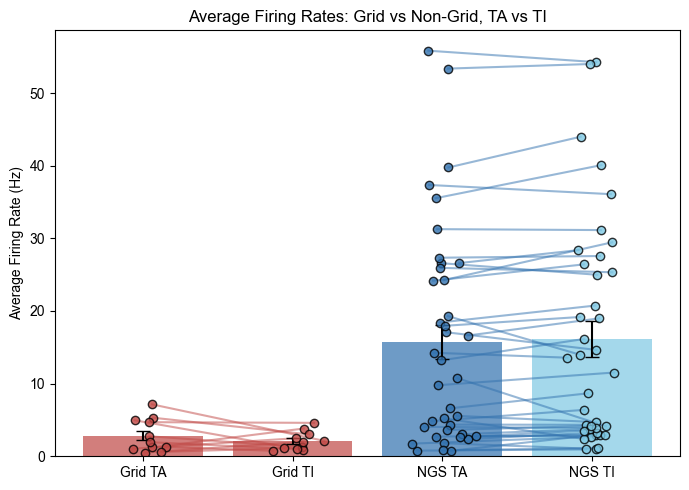

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume tcs_time is a dict: {cell_id: firing_rate_time_series}
# Assume trial_labels is a 1D array: 1 for TA, 0 for TI
# Assume trial_number_in_time is a 1D array mapping each timepoint to a trial number
# Assume g_m_cluster_ids[0] is grid cell ids, ngs.cluster_id.values is non-grid cell ids
# Assume time_bs is the bin size in milliseconds

ta_trials = beh['trials'][:len(trial_labels)][trial_labels == 1]['number'].values
ti_trials = beh['trials'][:len(trial_labels)][trial_labels == 0]['number'].values

ta_mask = np.isin(trial_number_in_time, ta_trials)
ti_mask = np.isin(trial_number_in_time, ti_trials)

grid_cell_ids = g_m_cluster_ids[0]
ngs_cell_ids = ngs.cluster_id.values

def firing_per_sec(cell_ids, mask):
    vals = [
        np.nanmean(np.array(tcs_time[cid])[mask]) * (1000.0 / time_bs)
        for cid in cell_ids if cid in tcs_time
    ]
    return np.array(vals)

grid_ta = firing_per_sec(grid_cell_ids, ta_mask)
grid_ti = firing_per_sec(grid_cell_ids, ti_mask)
ngs_ta = firing_per_sec(ngs_cell_ids, ta_mask)
ngs_ti = firing_per_sec(ngs_cell_ids, ti_mask)

means = [np.nanmean(grid_ta), np.nanmean(grid_ti), np.nanmean(ngs_ta), np.nanmean(ngs_ti)]
sems = [np.nanstd(grid_ta)/np.sqrt(len(grid_ta)), np.nanstd(grid_ti)/np.sqrt(len(grid_ti)),
        np.nanstd(ngs_ta)/np.sqrt(len(ngs_ta)), np.nanstd(ngs_ti)/np.sqrt(len(ngs_ti))]

labels = ['Grid TA', 'Grid TI', 'NGS TA', 'NGS TI']
colors = ['#c04744', '#c04744', '#3171ae', '#7ec8e3']

plt.figure(figsize=(7,5))
bar = plt.bar(labels, means, yerr=sems, color=colors, capsize=5, alpha=0.7, zorder=1)

# Add individual points and lines linking TA/TI for each cell
x_jitter = 0.08
# For grid cells
n_grid = min(len(grid_ta), len(grid_ti))
x1_grid = np.random.normal(0, x_jitter, size=n_grid)
x2_grid = np.random.normal(1, x_jitter, size=n_grid)
plt.scatter(x1_grid, grid_ta[:n_grid], color=colors[0], edgecolor='k', alpha=0.8, zorder=2)
plt.scatter(x2_grid, grid_ti[:n_grid], color=colors[1], edgecolor='k', alpha=0.8, zorder=2)
for xi1, yi1, xi2, yi2 in zip(x1_grid, grid_ta[:n_grid], x2_grid, grid_ti[:n_grid]):
    plt.plot([xi1, xi2], [yi1, yi2], color=colors[0], alpha=0.5, zorder=1)

# For non-grid cells
n_ngs = min(len(ngs_ta), len(ngs_ti))
x1_ngs = np.random.normal(2, x_jitter, size=n_ngs)
x2_ngs = np.random.normal(3, x_jitter, size=n_ngs)
plt.scatter(x1_ngs, ngs_ta[:n_ngs], color=colors[2], edgecolor='k', alpha=0.8, zorder=2)
plt.scatter(x2_ngs, ngs_ti[:n_ngs], color=colors[3], edgecolor='k', alpha=0.8, zorder=2)
for xi1, yi1, xi2, yi2 in zip(x1_ngs, ngs_ta[:n_ngs], x2_ngs, ngs_ti[:n_ngs]):
    plt.plot([xi1, xi2], [yi1, yi2], color=colors[2], alpha=0.5, zorder=1)

plt.ylabel('Average Firing Rate (Hz)')
plt.title('Average Firing Rates: Grid vs Non-Grid, TA vs TI')
plt.tight_layout()
plt.show()

In [10]:
module_1_ids = g_m_cluster_ids[0].copy()
module_1_ids.remove(test_grid_cell_id)
module_2_ids = g_m_cluster_ids[1].copy()
module_3_ids = g_m_cluster_ids[2].copy()
ngs_ids = ngs.cluster_id.values.tolist()

# Create feature matrix for all cells except the test cell
all_cell_ids = all.cluster_id.values.tolist()
all_cells_except_test = [cid for cid in all_cell_ids if cid != test_grid_cell_id and cid in tcs_time]

cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
cov_tcs_time_module_2 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_2_ids if cluster_id in tcs_time} 
cov_tcs_time_module_3 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_3_ids if cluster_id in tcs_time}
cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_ids if cluster_id in tcs_time}

In [11]:
y = np.array(tcs_time[test_grid_cell_id]) # target variable is the test grid cell
y_smoothed = gaussian_filter_nan(y, sigma=3) # smooth the target variable
X  = np.stack([pos_in_time]).T # pos in time

Xg1 = np.stack([np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T # co modular grid cell
Xg2 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T # non co modular grid cell
Xg3 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T # another non co modular grid cell
Xngs4 = np.stack([np.array(tcs_time[predictor_ngs_cell_id])]).T # ngs cell 2

Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T # co modular grid cell + pos in time
Xpos_g2 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T # non co modular grid cell + pos in time
Xpos_g3 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T # another non co modular grid cell + pos in time
Xpos_ngs4 = np.stack([pos_in_time, np.array(tcs_time[predictor_ngs_cell_id])]).T # ngs cell 2 + pos in time

Xm1 = np.column_stack((np.vstack(list(cov_tcs_time_module_1.values())).T)).T # module 1 grid cells
Xm2 = np.column_stack((np.vstack(list(cov_tcs_time_module_2.values())).T)).T # module 2 grid cells
Xm3 = np.column_stack((np.vstack(list(cov_tcs_time_module_3.values())).T)).T # module 3 grid cells
Xngs = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T # non grid cells
Xall = np.stack([np.array(tcs_time[cid]) for cid in all_cells_except_test]).T  # all cells except test

Xpos_m1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_1.values())).T)) # module 1 grid cells + pos in time
Xpos_m2 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_2.values())).T)) # module 2 grid cells + pos in time
Xpos_m3 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_3.values())).T)) # module 3 grid cells + pos in time
Xpos_ngs = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T)) # non grid cells + pos in time
Xpos_all = np.column_stack((pos_in_time, Xall))  # position + all cells

# single cell covariate
Y_hat_p, pR2_condition_cv_p = xgb_history.fit_cv(X, y, verbose = 2, continuous_folds = True)
Y_hat_g1, pR2_condition_cv_g1 = xgb_history.fit_cv(Xg1, y, verbose = 2, continuous_folds = True)
Y_hat_g2, pR2_condition_cv_g2 = xgb_history.fit_cv(Xg2, y, verbose = 2, continuous_folds = True)
Y_hat_g3, pR2_condition_cv_g3 = xgb_history.fit_cv(Xg3, y, verbose = 2, continuous_folds = True)
Y_hat_ngs4, pR2_condition_cv_ngs4 = xgb_history.fit_cv(Xngs4, y, verbose = 2, continuous_folds = True)
Y_hat_pos_g1, pR2_condition_cv_pos_g1 = xgb_history.fit_cv(Xpos_g1, y, verbose = 2, continuous_folds = True)
Y_hat_pos_g2, pR2_condition_cv_pos_g2 = xgb_history.fit_cv(Xpos_g2, y, verbose = 2, continuous_folds = True)
Y_hat_pos_g3, pR2_condition_cv_pos_g3 = xgb_history.fit_cv(Xpos_g3, y, verbose = 2, continuous_folds = True)
Y_hat_pos_ngs4, pR2_condition_cv_pos_ngs4 = xgb_history.fit_cv(Xpos_ngs4, y, verbose = 2, continuous_folds = True)

# multiple cell covariate
Y_hat_m1, pR2_condition_cv_m1 = xgb_history.fit_cv(Xm1, y, verbose = 2, continuous_folds = True)
Y_hat_m2, pR2_condition_cv_m2 = xgb_history.fit_cv(Xm2, y, verbose = 2, continuous_folds = True)
Y_hat_m3, pR2_condition_cv_m3 = xgb_history.fit_cv(Xm3, y, verbose = 2, continuous_folds = True)
Y_hat_ngs, pR2_condition_cv_ngs = xgb_history.fit_cv(Xngs, y, verbose = 2, continuous_folds = True)
Y_hat_all, pR2_condition_cv_all = xgb_history.fit_cv(Xall, y, verbose=2, continuous_folds=True)
Y_hat_pos_m1, pR2_condition_cv_pos_m1 = xgb_history.fit_cv(Xpos_m1, y, verbose = 2, continuous_folds = True)
Y_hat_pos_m2, pR2_condition_cv_pos_m2 = xgb_history.fit_cv(Xpos_m2, y, verbose = 2, continuous_folds = True)
Y_hat_pos_m3, pR2_condition_cv_pos_m3 = xgb_history.fit_cv(Xpos_m3, y, verbose = 2, continuous_folds = True)
Y_hat_pos_ngs, pR2_condition_cv_pos_ngs4 = xgb_history.fit_cv(Xpos_ngs, y, verbose = 2, continuous_folds = True)
Y_hat_pos_all, pR2_condition_cv_pos_all = xgb_history.fit_cv(Xpos_all, y, verbose=2, continuous_folds=True)


...runnning cv-fold 0 of 10
pR2:  -0.0965938939171973
...runnning cv-fold 1 of 10
pR2:  0.11132727968893041
...runnning cv-fold 2 of 10
pR2:  0.06279643969333804
...runnning cv-fold 3 of 10
pR2:  0.07756494101638833
...runnning cv-fold 4 of 10
pR2:  0.09777688448684618
...runnning cv-fold 5 of 10
pR2:  0.10221830813424715
...runnning cv-fold 6 of 10
pR2:  -0.033960062638433985
...runnning cv-fold 7 of 10
pR2:  0.10561764300437093
...runnning cv-fold 8 of 10
pR2:  0.10930643783886018
...runnning cv-fold 9 of 10
pR2:  0.14869561441381163
pR2_cv: 0.068475 (+/- 0.022621)
...runnning cv-fold 0 of 10
pR2:  0.012702647747567353
...runnning cv-fold 1 of 10
pR2:  0.02090023012517117
...runnning cv-fold 2 of 10
pR2:  0.0194116019039009
...runnning cv-fold 3 of 10
pR2:  0.02598520744510535
...runnning cv-fold 4 of 10
pR2:  0.02473820081836009
...runnning cv-fold 5 of 10
pR2:  0.04278662947699363
...runnning cv-fold 6 of 10
pR2:  0.021740467644480677
...runnning cv-fold 7 of 10
pR2:  0.02156977283

In [12]:
expected_spikes = {test_grid_cell_id: Y_hat_p
                   }

# use the cluster_ids for the ns group as a trick to push it though the reconstruction function
expected_spikes[97] = Y_hat_m1
expected_spikes[102] = Y_hat_m2
expected_spikes[192] = Y_hat_m3
expected_spikes[245] = Y_hat_ngs
expected_spikes[293] = Y_hat_all

tcs_expected_spikes, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(mouse, day, apply_zscore=False, vr_type='VR', 
                                                                                          source_path=None, expected_spikes=expected_spikes)

trial_groups, trial_colors = get_trial_groups_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)
sorted_trial_indices, sorted_trial_colors = get_sorted_trials_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)


using expected spikes for cell 97
using expected spikes for cell 102
using expected spikes for cell 172
using expected spikes for cell 192
using expected spikes for cell 245
using expected spikes for cell 293


In [13]:
def compute_rolling_pr2(y_true, y_pred, trial_numbers, window_size=10):
    """
    Compute rolling pR2 values across trials using Poisson pseudo-R2.
    
    Parameters:
    -----------
    y_true : array
        True values (ground truth)
    y_pred : array  
        Predicted values
    trial_numbers : array
        Trial numbers for each time point
    window_size : int
        Number of trials to include in each rolling window
        
    Returns:
    --------
    unique_trials : array
        Trial numbers
    rolling_pr2 : array
        Rolling pR2 values for each trial
    """
    # Import the poisson_pseudoR2 function from mlencoding
    from spatial_manifolds.mlencoding import poisson_pseudoR2
    
    unique_trials = np.unique(trial_numbers)
    rolling_pr2 = np.full(len(unique_trials), np.nan)
    
    for i, trial in enumerate(unique_trials):
        # Define window around current trial
        start_trial = max(0, i - window_size//2)
        end_trial = min(len(unique_trials), i + window_size//2 + 1)
        window_trials = unique_trials[start_trial:end_trial]
        
        # Get indices for trials in window
        window_mask = np.isin(trial_numbers, window_trials)
        
        if np.sum(window_mask) > 10:  # Need minimum number of points
            y_true_window = y_true[window_mask]
            y_pred_window = y_pred[window_mask]
            
            # Remove NaN values
            valid_mask = ~(np.isnan(y_true_window) | np.isnan(y_pred_window))
            if np.sum(valid_mask) > 5:
                y_true_clean = y_true_window[valid_mask]
                y_pred_clean = y_pred_window[valid_mask]
                
                # Compute null model (mean activity in the window)
                y_null = np.mean(y_true_clean)
                
                # Compute Poisson pseudo-R2
                if len(y_true_clean) > 1 and np.var(y_true_clean) > 0:
                    pr2 = poisson_pseudoR2(y_true_clean, y_pred_clean, y_null)
                    rolling_pr2[i] = pr2 if not np.isnan(pr2) else 0
    
    return unique_trials, rolling_pr2


def compute_rolling_pr2_for_all_predictions(y_true, trial_numbers, predictions_dict, window_size=10):
    """
    Compute rolling pR2 for all prediction conditions using Poisson pseudo-R2.
    
    Parameters:
    -----------
    y_true : array
        True values (target cell activity)
    trial_numbers : array
        Trial numbers for each time point  
    predictions_dict : dict
        Dictionary with prediction names as keys and predicted values as values
    window_size : int
        Number of trials for rolling window
        
    Returns:
    --------
    results_df : DataFrame
        DataFrame with trial numbers and rolling pR2 for each condition
    """
    unique_trials = np.unique(trial_numbers)
    results = {'trial_number': unique_trials}
    
    for pred_name, y_pred in predictions_dict.items():
        _, rolling_pr2 = compute_rolling_pr2(y_true, y_pred, trial_numbers, window_size)
        results[f'rolling_pr2_{pred_name}'] = rolling_pr2
    
    return pd.DataFrame(results)

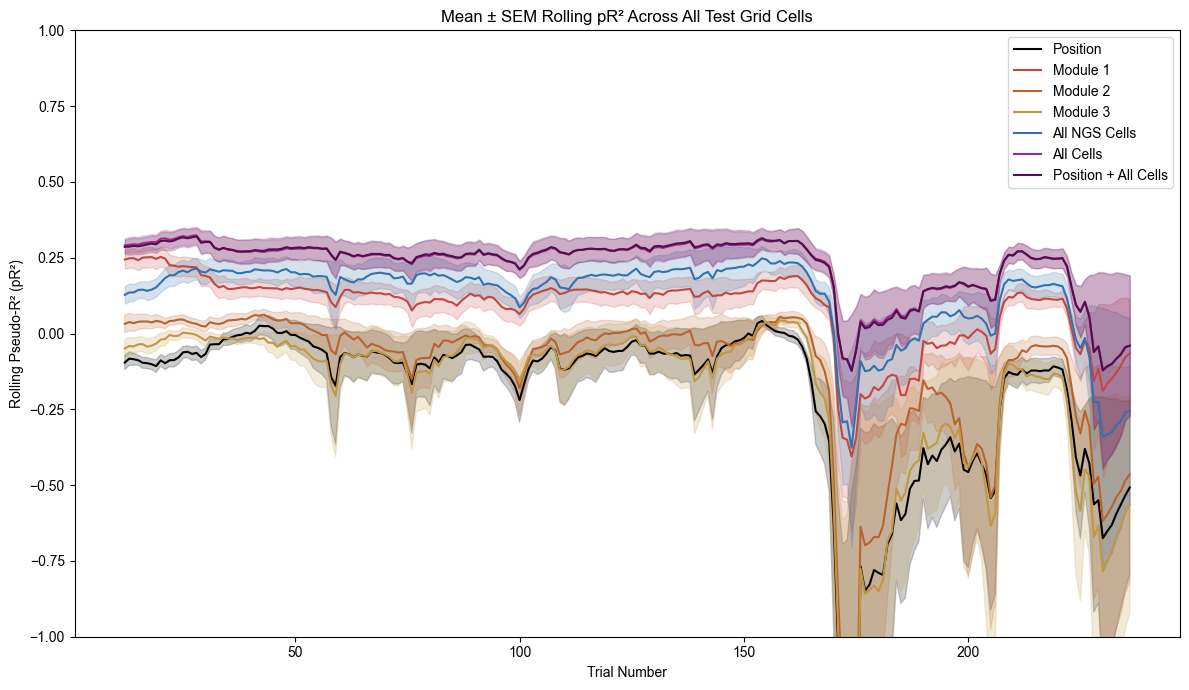

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Store rolling pR² results for each test cell
all_rolling_results = []

for test_grid_cell_id in g_m_cluster_ids[0].copy():
    module_1_ids = g_m_cluster_ids[0].copy()
    module_1_ids.remove(test_grid_cell_id)
    module_2_ids = g_m_cluster_ids[1].copy()
    module_3_ids = g_m_cluster_ids[2].copy()
    ngs_ids = ngs.cluster_id.values.tolist()

    all_cell_ids = all.cluster_id.values.tolist()
    all_cells_except_test = [cid for cid in all_cell_ids if cid != test_grid_cell_id and cid in tcs_time]

    cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
    cov_tcs_time_module_2 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_2_ids if cluster_id in tcs_time} 
    cov_tcs_time_module_3 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_3_ids if cluster_id in tcs_time}
    cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_ids if cluster_id in tcs_time}

    y = np.array(tcs_time[test_grid_cell_id])
    y_smoothed = gaussian_filter_nan(y, sigma=3)
    X  = np.stack([pos_in_time]).T

    Xg1 = np.stack([np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
    Xg2 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
    Xg3 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T
    Xngs4 = np.stack([np.array(tcs_time[predictor_ngs_cell_id])]).T

    Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
    Xpos_g2 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
    Xpos_g3 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T
    Xpos_ngs4 = np.stack([pos_in_time, np.array(tcs_time[predictor_ngs_cell_id])]).T

    Xm1 = np.column_stack((np.vstack(list(cov_tcs_time_module_1.values())).T)).T
    Xm2 = np.column_stack((np.vstack(list(cov_tcs_time_module_2.values())).T)).T
    Xm3 = np.column_stack((np.vstack(list(cov_tcs_time_module_3.values())).T)).T
    Xngs = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T
    Xall = np.stack([np.array(tcs_time[cid]) for cid in all_cells_except_test]).T

    Xpos_m1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_1.values())).T))
    Xpos_m2 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_2.values())).T))
    Xpos_m3 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_3.values())).T))
    Xpos_ngs = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T))
    Xpos_all = np.column_stack((pos_in_time, Xall))

    # single cell covariate
    Y_hat_p, _ = xgb_history.fit_cv(X, y, verbose=0, continuous_folds=True)
    Y_hat_g1, _ = xgb_history.fit_cv(Xg1, y, verbose=0, continuous_folds=True)
    Y_hat_g2, _ = xgb_history.fit_cv(Xg2, y, verbose=0, continuous_folds=True)
    Y_hat_g3, _ = xgb_history.fit_cv(Xg3, y, verbose=0, continuous_folds=True)
    Y_hat_ngs4, _ = xgb_history.fit_cv(Xngs4, y, verbose=0, continuous_folds=True)
    Y_hat_pos_g1, _ = xgb_history.fit_cv(Xpos_g1, y, verbose=0, continuous_folds=True)
    Y_hat_pos_g2, _ = xgb_history.fit_cv(Xpos_g2, y, verbose=0, continuous_folds=True)
    Y_hat_pos_g3, _ = xgb_history.fit_cv(Xpos_g3, y, verbose=0, continuous_folds=True)
    Y_hat_pos_ngs4, _ = xgb_history.fit_cv(Xpos_ngs4, y, verbose=0, continuous_folds=True)

    # multiple cell covariate
    Y_hat_m1, _ = xgb_history.fit_cv(Xm1, y, verbose=0, continuous_folds=True)
    Y_hat_m2, _ = xgb_history.fit_cv(Xm2, y, verbose=0, continuous_folds=True)
    Y_hat_m3, _ = xgb_history.fit_cv(Xm3, y, verbose=0, continuous_folds=True)
    Y_hat_ngs, _ = xgb_history.fit_cv(Xngs, y, verbose=0, continuous_folds=True)
    Y_hat_all, _ = xgb_history.fit_cv(Xall, y, verbose=0, continuous_folds=True)
    Y_hat_pos_m1, _ = xgb_history.fit_cv(Xpos_m1, y, verbose=0, continuous_folds=True)
    Y_hat_pos_m2, _ = xgb_history.fit_cv(Xpos_m2, y, verbose=0, continuous_folds=True)
    Y_hat_pos_m3, _ = xgb_history.fit_cv(Xpos_m3, y, verbose=0, continuous_folds=True)
    Y_hat_pos_ngs, _ = xgb_history.fit_cv(Xpos_ngs, y, verbose=0, continuous_folds=True)
    Y_hat_pos_all, _ = xgb_history.fit_cv(Xpos_all, y, verbose=0, continuous_folds=True)

    y_full = np.array(tcs_time[test_grid_cell_id])

    predictions_dict = {
        'position': Y_hat_p,
        'grid_co_modular': Y_hat_g1,
        'grid_non_co_modular_1': Y_hat_g2,
        'grid_non_co_modular_2': Y_hat_g3,
        'non_grid_spatial': Y_hat_ngs4,
        'position_plus_grid_co_modular': Y_hat_pos_g1,
        'position_plus_grid_non_co_modular_1': Y_hat_pos_g2,
        'position_plus_grid_non_co_modular_2': Y_hat_pos_g3,
        'position_plus_non_grid_spatial': Y_hat_pos_ngs4,
        'module_1': Y_hat_m1,
        'module_2': Y_hat_m2,
        'module_3': Y_hat_m3,
        'all_non_grid_spatial': Y_hat_ngs,
        'all_cells': Y_hat_all,
        'position_plus_module_1': Y_hat_pos_m1,
        'position_plus_module_2': Y_hat_pos_m2,
        'position_plus_module_3': Y_hat_pos_m3,
        'position_plus_all_non_grid_spatial': Y_hat_pos_ngs,
        'position_plus_all_cells': Y_hat_pos_all,
    }

    rolling_pr2_results = compute_rolling_pr2_for_all_predictions(
        y_true=y_full, 
        trial_numbers=trial_number_in_time,
        predictions_dict=predictions_dict,
        window_size=15
    )
    rolling_pr2_results['test_grid_cell_id'] = test_grid_cell_id
    all_rolling_results.append(rolling_pr2_results)

# Combine all rolling results into a single DataFrame
all_rolling_df = pd.concat(all_rolling_results, ignore_index=True)

# Compute mean and standard error for each predictor at each trial
predictor_cols = [col for col in all_rolling_df.columns if col.startswith('rolling_pr2_')]
grouped = all_rolling_df.groupby('trial_number')

mean_df = grouped[predictor_cols].mean()
sem_df = grouped[predictor_cols].sem()

# Plot mean ± SEM for each predictor
plt.figure(figsize=(12, 7))
colors = {
    'rolling_pr2_position': '#000000',
    'rolling_pr2_module_1': '#c04744',
    'rolling_pr2_module_2': '#B6632F',
    'rolling_pr2_module_3': '#c09744',
    'rolling_pr2_all_non_grid_spatial': '#3171ae',
    'rolling_pr2_all_cells': "#A12786",
    'rolling_pr2_position_plus_all_cells': "#50104c"
}
labels = {
    'rolling_pr2_position': 'Position',
    'rolling_pr2_module_1': 'Module 1',
    'rolling_pr2_module_2': 'Module 2',
    'rolling_pr2_module_3': 'Module 3',
    'rolling_pr2_all_non_grid_spatial': 'All NGS Cells',
    'rolling_pr2_all_cells': 'All Cells',
    'rolling_pr2_position_plus_all_cells': 'Position + All Cells'
}
for col in colors:
    if col in mean_df.columns:
        plt.plot(mean_df.index, mean_df[col], color=colors[col], label=labels[col])
        plt.fill_between(mean_df.index, mean_df[col] - sem_df[col], mean_df[col] + sem_df[col], color=colors[col], alpha=0.2)
plt.xlabel('Trial Number')
plt.ylabel('Rolling Pseudo-R² (pR²)')
plt.ylim(-1,1)
plt.title('Mean ± SEM Rolling pR² Across All Test Grid Cells')
plt.legend()
plt.tight_layout()
plt.show()

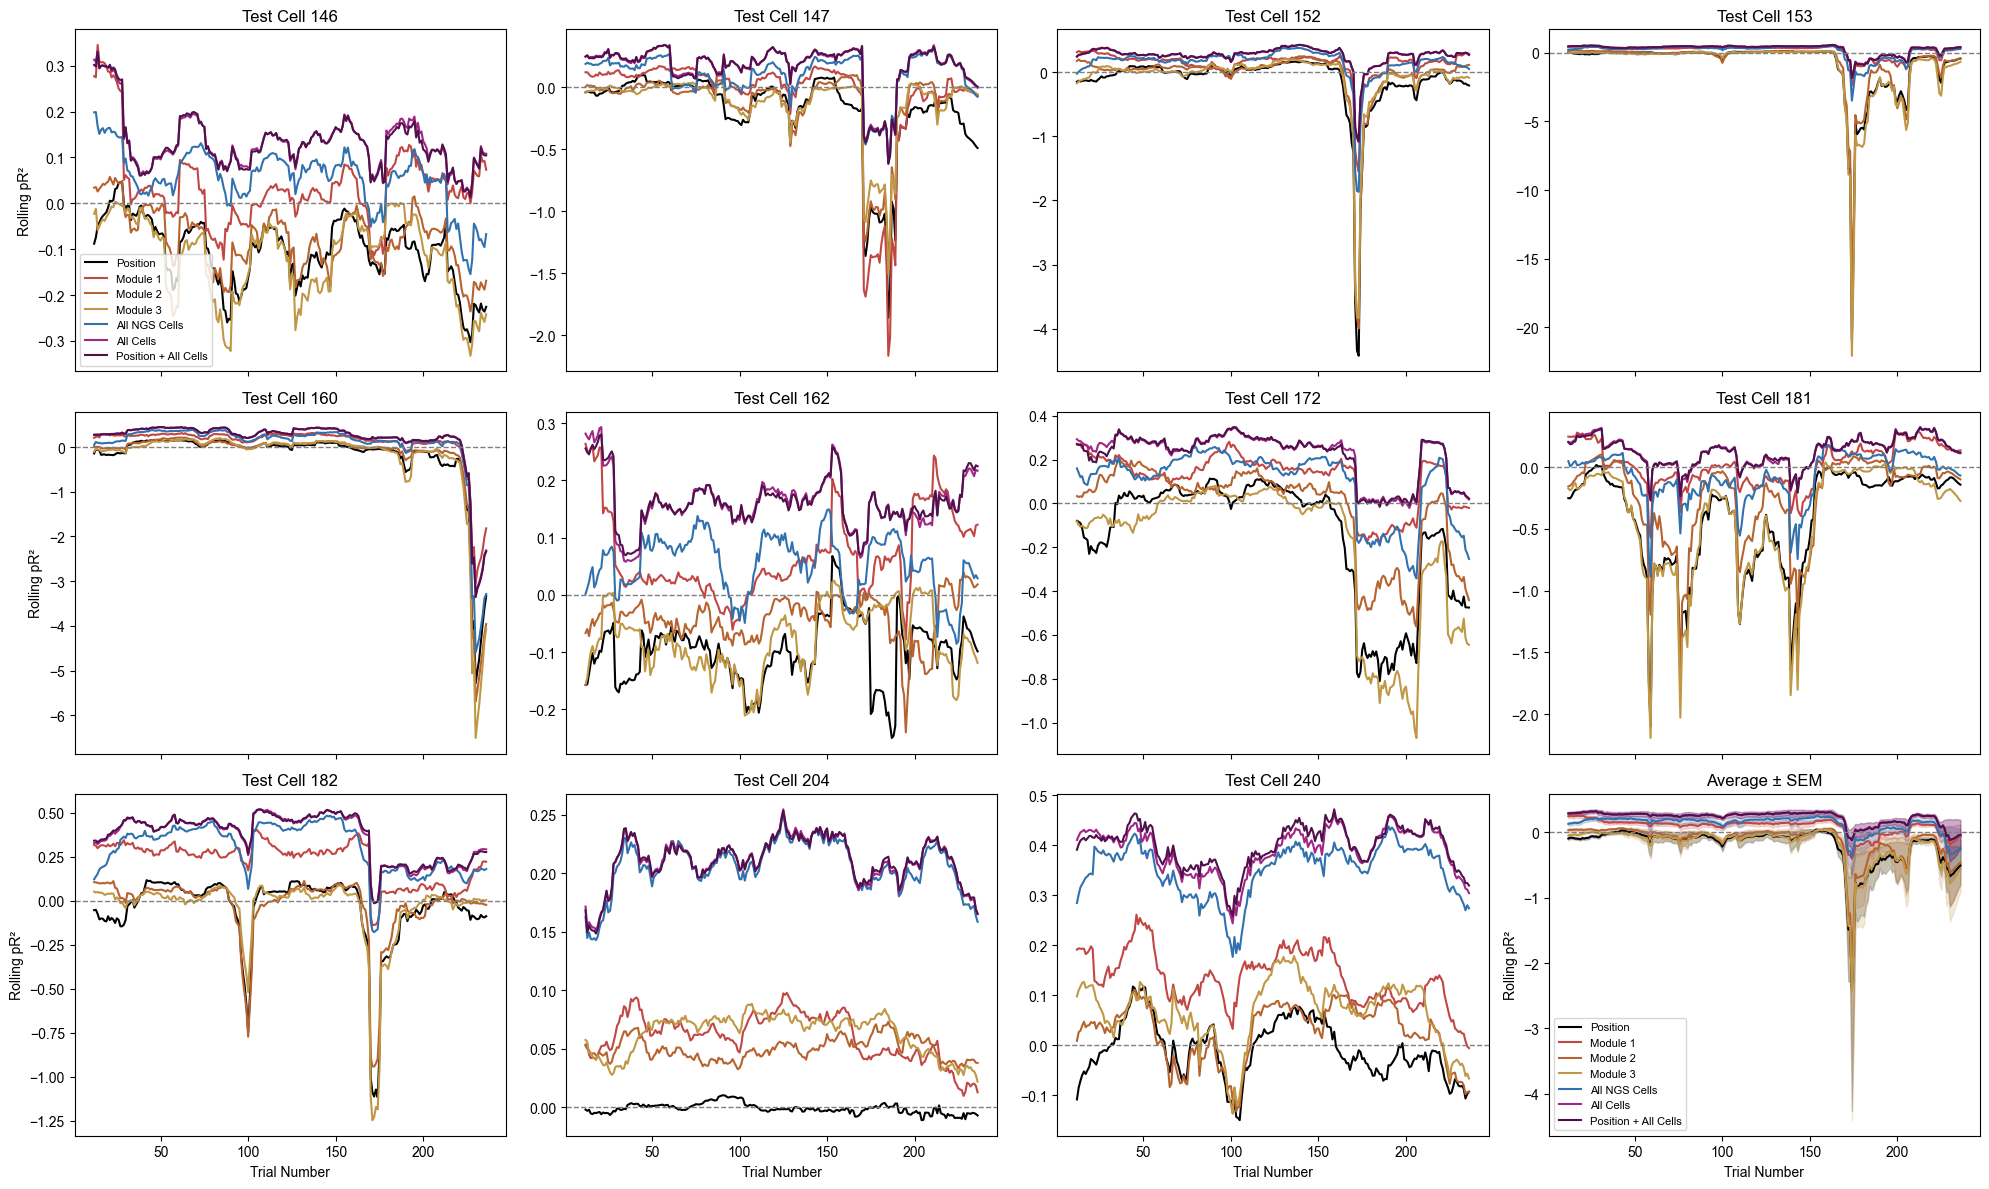

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Combine all rolling results into a single DataFrame if not already done
all_rolling_df = pd.concat(all_rolling_results, ignore_index=True)

# Get unique test_grid_cell_ids and predictors to plot
test_ids = all_rolling_df['test_grid_cell_id'].unique()
predictors_to_plot = [
    'rolling_pr2_position',
    'rolling_pr2_module_1',
    'rolling_pr2_module_2',
    'rolling_pr2_module_3',
    'rolling_pr2_all_non_grid_spatial',
    'rolling_pr2_all_cells',
    'rolling_pr2_position_plus_all_cells'
]
labels = {
    'rolling_pr2_position': 'Position',
    'rolling_pr2_module_1': 'Module 1',
    'rolling_pr2_module_2': 'Module 2',
    'rolling_pr2_module_3': 'Module 3',
    'rolling_pr2_all_non_grid_spatial': 'All NGS Cells',
    'rolling_pr2_all_cells': 'All Cells',
    'rolling_pr2_position_plus_all_cells': 'Position + All Cells'
}
colors = {
    'rolling_pr2_position': '#000000',
    'rolling_pr2_module_1': '#c04744',
    'rolling_pr2_module_2': '#B6632F',
    'rolling_pr2_module_3': '#c09744',
    'rolling_pr2_all_non_grid_spatial': '#3171ae',
    'rolling_pr2_all_cells': "#A12786",
    'rolling_pr2_position_plus_all_cells': "#50104c"
}

# Set up subplot grid (add 1 for the average plot)
n_cells = len(test_ids)
n_cols = 4
n_rows = int(np.ceil((n_cells + 1) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), sharex=True, sharey=False)

for idx, test_id in enumerate(test_ids):
    ax = axes.flat[idx]
    cell_df = all_rolling_df[all_rolling_df['test_grid_cell_id'] == test_id]
    for pred in predictors_to_plot:
        if pred in cell_df.columns:
            ax.plot(cell_df['trial_number'], cell_df[pred], color=colors[pred], label=labels[pred])
    ax.set_title(f"Test Cell {test_id}")
    #ax.set_ylim(-0.1, 0.3)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    if idx % n_cols == 0:
        ax.set_ylabel('Rolling pR²')
    if idx >= (n_rows-1)*n_cols:
        ax.set_xlabel('Trial Number')
    if idx == 0:
        ax.legend(fontsize=8)

# Average plot as the final subplot
mean_df = all_rolling_df.groupby('trial_number')[predictors_to_plot].mean()
sem_df = all_rolling_df.groupby('trial_number')[predictors_to_plot].sem()
ax = axes.flat[n_cells]
for pred in predictors_to_plot:
    if pred in mean_df.columns:
        ax.plot(mean_df.index, mean_df[pred], color=colors[pred], label=labels[pred])
        ax.fill_between(mean_df.index, mean_df[pred] - sem_df[pred], mean_df[pred] + sem_df[pred], color=colors[pred], alpha=0.2)
ax.set_title('Average ± SEM')
#ax.set_ylim(-0.1, 0.3)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Trial Number')
ax.set_ylabel('Rolling pR²')
ax.legend(fontsize=8)

# Hide any unused subplots
for j in range(n_cells+1, n_rows*n_cols):
    fig.delaxes(axes.flat[j])

plt.tight_layout()
plt.show()

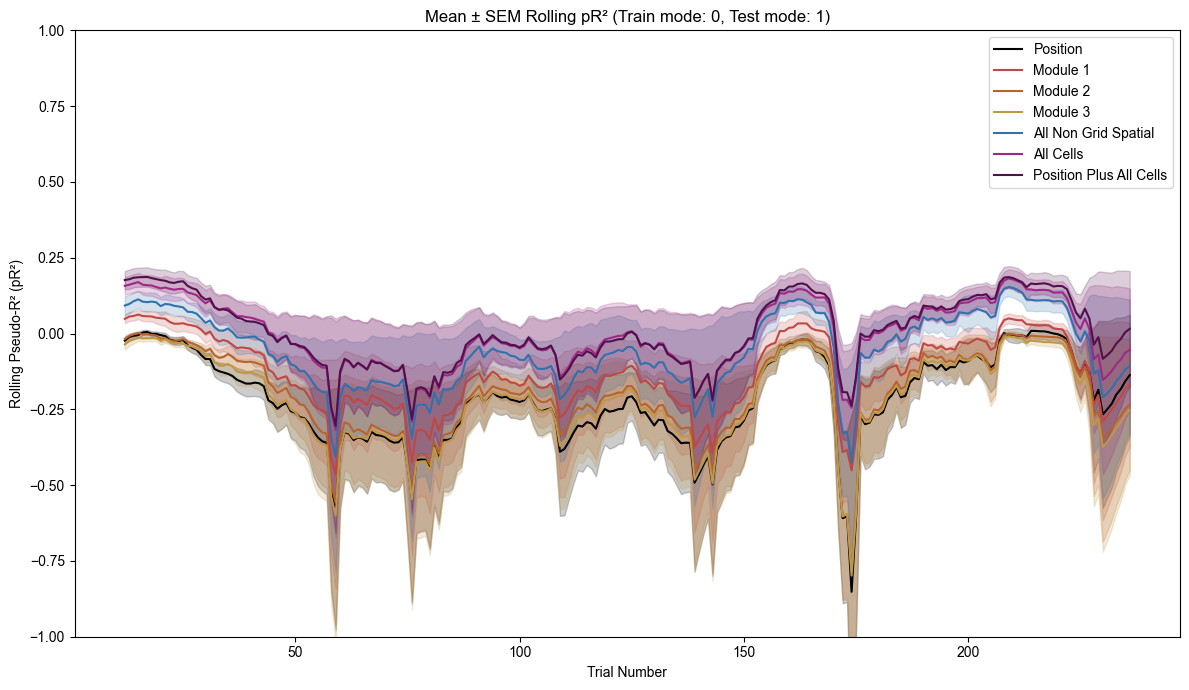

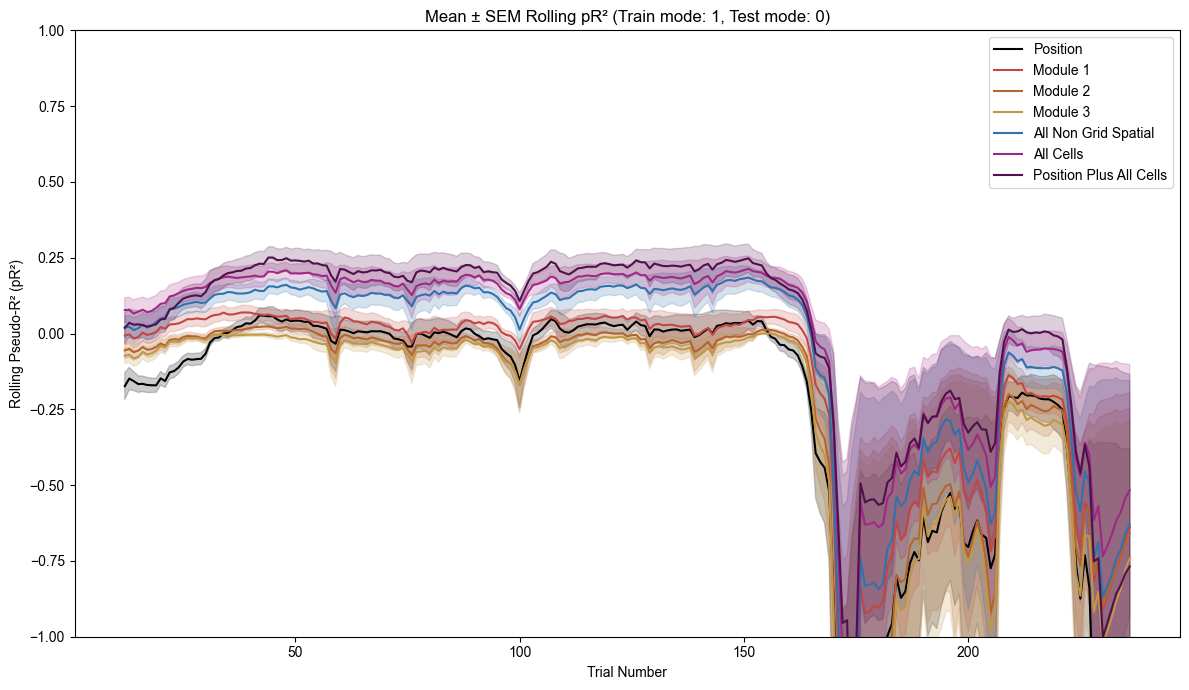

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

all_rolling_results = []

for test_grid_cell_id in g_m_cluster_ids[0].copy():
    module_1_ids = g_m_cluster_ids[0].copy()
    module_1_ids.remove(test_grid_cell_id)
    module_2_ids = g_m_cluster_ids[1].copy()
    module_3_ids = g_m_cluster_ids[2].copy()
    ngs_ids = ngs.cluster_id.values.tolist()

    all_cell_ids = all.cluster_id.values.tolist()
    all_cells_except_test = [cid for cid in all_cell_ids if cid != test_grid_cell_id and cid in tcs_time]

    cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
    cov_tcs_time_module_2 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_2_ids if cluster_id in tcs_time} 
    cov_tcs_time_module_3 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_3_ids if cluster_id in tcs_time}
    cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_ids if cluster_id in tcs_time}

    y = np.array(tcs_time[test_grid_cell_id])
    y_smoothed = gaussian_filter_nan(y, sigma=3)
    X  = np.stack([pos_in_time]).T

    Xg1 = np.stack([np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
    Xg2 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
    Xg3 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T
    Xngs4 = np.stack([np.array(tcs_time[predictor_ngs_cell_id])]).T

    Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
    Xpos_g2 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
    Xpos_g3 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T
    Xpos_ngs4 = np.stack([pos_in_time, np.array(tcs_time[predictor_ngs_cell_id])]).T

    Xm1 = np.column_stack((np.vstack(list(cov_tcs_time_module_1.values())).T)).T
    Xm2 = np.column_stack((np.vstack(list(cov_tcs_time_module_2.values())).T)).T
    Xm3 = np.column_stack((np.vstack(list(cov_tcs_time_module_3.values())).T)).T
    Xngs = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T
    Xall = np.stack([np.array(tcs_time[cid]) for cid in all_cells_except_test]).T

    Xpos_m1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_1.values())).T))
    Xpos_m2 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_2.values())).T))
    Xpos_m3 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_3.values())).T))
    Xpos_ngs = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T))
    Xpos_all = np.column_stack((pos_in_time, Xall))

    # Prepare all predictors
    predictors = {
        'position': X,
        'grid_co_modular': Xg1,
        'grid_non_co_modular_1': Xg2,
        'grid_non_co_modular_2': Xg3,
        'non_grid_spatial': Xngs4,
        'position_plus_grid_co_modular': Xpos_g1,
        'position_plus_grid_non_co_modular_1': Xpos_g2,
        'position_plus_grid_non_co_modular_2': Xpos_g3,
        'position_plus_non_grid_spatial': Xpos_ngs4,
        'module_1': Xm1,
        'module_2': Xm2,
        'module_3': Xm3,
        'all_non_grid_spatial': Xngs,
        'all_cells': Xall,
        'position_plus_module_1': Xpos_m1,
        'position_plus_module_2': Xpos_m2,
        'position_plus_module_3': Xpos_m3,
        'position_plus_all_non_grid_spatial': Xpos_ngs,
        'position_plus_all_cells': Xpos_all,
    }

    # For each training/testing mode (e.g., task-anchored vs non-task-anchored)
    for training_mode, testing_mode in zip([1,0], [0,1]):
        train_trials = beh['trials'][:len(trial_labels)]
        test_trials = beh['trials'][:len(trial_labels)]

        train_trials = train_trials[trial_labels == training_mode]['number'].values
        test_trials = test_trials[trial_labels == testing_mode]['number'].values

        train_mask = np.isin(trial_number_in_time, train_trials)
        test_mask = np.isin(trial_number_in_time, test_trials)

        train_indices = np.where(train_mask)[0]
        test_indices = np.where(test_mask)[0]

        y_full = np.array(tcs_time[test_grid_cell_id])

        predictions_dict = {}
        for name, Xmat in predictors.items():
            # Use fit_cv_and_predefined_set for each predictor
            Y_hat, _ = xgb_history.fit_cv_and_predefined_set(
                Xmat, y_full, train_indices, test_indices, n_cv=10, verbose=0, continuous_folds=True
            )
            predictions_dict[name] = Y_hat

        rolling_pr2_results = compute_rolling_pr2_for_all_predictions(
            y_true=y_full, 
            trial_numbers=trial_number_in_time,
            predictions_dict=predictions_dict,
            window_size=15
        )
        rolling_pr2_results['test_grid_cell_id'] = test_grid_cell_id
        rolling_pr2_results['train_mode'] = training_mode
        rolling_pr2_results['test_mode'] = testing_mode
        all_rolling_results.append(rolling_pr2_results)

# Combine all rolling results into a single DataFrame
all_rolling_df = pd.concat(all_rolling_results, ignore_index=True)

# Compute mean and standard error for each predictor at each trial, for each train/test mode
predictor_cols = [col for col in all_rolling_df.columns if col.startswith('rolling_pr2_')]
grouped = all_rolling_df.groupby(['train_mode', 'test_mode', 'trial_number'])

mean_df = grouped[predictor_cols].mean()
sem_df = grouped[predictor_cols].sem()

# Plot mean ± SEM for each predictor, for each train/test mode
for (train_mode, test_mode), group in mean_df.groupby(level=[0,1]):
    plt.figure(figsize=(12, 7))
    for col, color in {
        'rolling_pr2_position': '#000000',
        'rolling_pr2_module_1': '#c04744',
        'rolling_pr2_module_2': '#B6632F',
        'rolling_pr2_module_3': '#c09744',
        'rolling_pr2_all_non_grid_spatial': '#3171ae',
        'rolling_pr2_all_cells': "#A12786",
        'rolling_pr2_position_plus_all_cells': "#50104c"
    }.items():
        if col in group.columns:
            plt.plot(group.index.get_level_values('trial_number'), group[col], color=color, label=col.replace('rolling_pr2_', '').replace('_', ' ').title())
            plt.fill_between(
                group.index.get_level_values('trial_number'),
                group[col] - sem_df.loc[(train_mode, test_mode), col],
                group[col] + sem_df.loc[(train_mode, test_mode), col],
                color=color, alpha=0.2
            )
    plt.xlabel('Trial Number')
    plt.ylabel('Rolling Pseudo-R² (pR²)')
    plt.ylim(-1,1)
    plt.title(f'Mean ± SEM Rolling pR² (Train mode: {train_mode}, Test mode: {test_mode})')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Store rolling pR² results for each test cell
all_rolling_results = []

# Use only non-grid cells as test IDs
for test_ngs_cell_id in ngs.cluster_id.values.tolist():
    module_1_ids = g_m_cluster_ids[0].copy()
    module_2_ids = g_m_cluster_ids[1].copy()
    module_3_ids = g_m_cluster_ids[2].copy()
    ngs_ids = ngs.cluster_id.values.tolist()
    # Remove test cell from predictors if present
    ngs_ids_no_test = [cid for cid in ngs_ids if cid != test_ngs_cell_id]
    all_cell_ids = all.cluster_id.values.tolist()
    all_cells_except_test = [cid for cid in all_cell_ids if cid != test_ngs_cell_id and cid in tcs_time]

    cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
    cov_tcs_time_module_2 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_2_ids if cluster_id in tcs_time} 
    cov_tcs_time_module_3 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_3_ids if cluster_id in tcs_time}
    cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_ids_no_test if cluster_id in tcs_time}

    y = np.array(tcs_time[test_ngs_cell_id])
    y_smoothed = gaussian_filter_nan(y, sigma=3)
    X  = np.stack([pos_in_time]).T

    # For NGS cells, you may want to use other NGS cells as predictors, or all grid cells, or all cells
    Xngs = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T if len(cov_tcs_time_ngs) > 0 else np.empty((len(y), 0))
    Xall = np.stack([np.array(tcs_time[cid]) for cid in all_cells_except_test]).T

    Xpos_ngs = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T)) if len(cov_tcs_time_ngs) > 0 else np.column_stack((pos_in_time,))
    Xpos_all = np.column_stack((pos_in_time, Xall))

    # single cell covariate
    Y_hat_p, _ = xgb_history.fit_cv(X, y, verbose=0, continuous_folds=True)
    Y_hat_ngs, _ = xgb_history.fit_cv(Xngs, y, verbose=0, continuous_folds=True) if Xngs.shape[1] > 0 else (np.full_like(y, np.nan), None)
    Y_hat_all, _ = xgb_history.fit_cv(Xall, y, verbose=0, continuous_folds=True)
    Y_hat_pos_ngs, _ = xgb_history.fit_cv(Xpos_ngs, y, verbose=0, continuous_folds=True)
    Y_hat_pos_all, _ = xgb_history.fit_cv(Xpos_all, y, verbose=0, continuous_folds=True)

    y_full = np.array(tcs_time[test_ngs_cell_id])

    predictions_dict = {
        'position': Y_hat_p,
        'all_non_grid_spatial': Y_hat_ngs,
        'all_cells': Y_hat_all,
        'position_plus_all_non_grid_spatial': Y_hat_pos_ngs,
        'position_plus_all_cells': Y_hat_pos_all,
    }

    rolling_pr2_results = compute_rolling_pr2_for_all_predictions(
        y_true=y_full, 
        trial_numbers=trial_number_in_time,
        predictions_dict=predictions_dict,
        window_size=15
    )
    rolling_pr2_results['test_ngs_cell_id'] = test_ngs_cell_id
    all_rolling_results.append(rolling_pr2_results)

# Combine all rolling results into a single DataFrame
all_rolling_df = pd.concat(all_rolling_results, ignore_index=True)

# Compute mean and standard error for each predictor at each trial
predictor_cols = [col for col in all_rolling_df.columns if col.startswith('rolling_pr2_')]
grouped = all_rolling_df.groupby('trial_number')

mean_df = grouped[predictor_cols].mean()
sem_df = grouped[predictor_cols].sem()

# Plot mean ± SEM for each predictor
plt.figure(figsize=(12, 7))
colors = {
    'rolling_pr2_position': '#000000',
    'rolling_pr2_all_non_grid_spatial': '#3171ae',
    'rolling_pr2_all_cells': "#A12786",
    'rolling_pr2_position_plus_all_non_grid_spatial': "#2e8b57",
    'rolling_pr2_position_plus_all_cells': "#50104c"
}
labels = {
    'rolling_pr2_position': 'Position',
    'rolling_pr2_all_non_grid_spatial': 'All NGS Cells',
    'rolling_pr2_all_cells': 'All Cells',
    'rolling_pr2_position_plus_all_non_grid_spatial': 'Position + All NGS',
    'rolling_pr2_position_plus_all_cells': 'Position + All Cells'
}
for col in colors:
    if col in mean_df.columns:
        plt.plot(mean_df.index, mean_df[col], color=colors[col], label=labels[col])
        plt.fill_between(mean_df.index, mean_df[col] - sem_df[col], mean_df[col] + sem_df[col], color=colors[col], alpha=0.2)
plt.xlabel('Trial Number')
plt.ylabel('Rolling Pseudo-R² (pR²)')
plt.ylim(-1,1)
plt.title('Mean ± SEM Rolling pR² Across All Non-Grid Test Cells')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Store rolling pR² results for each test cell
all_rolling_results = []

for training_mode, testing_mode in zip([1,0], [0,1]): # 1 is task anchored, 0 is non task anchored

    # train model on TA trials and test on TA trials
    train_trials = beh['trials'][:len(trial_labels)]
    test_trials = beh['trials'][:len(trial_labels)]

    train_trials = train_trials[trial_labels == training_mode]['number'].values
    test_trials = test_trials[trial_labels == testing_mode]['number'].values

    train_mask = np.isin(trial_number_in_time, train_trials)
    test_mask = np.isin(trial_number_in_time, test_trials)


    for test_grid_cell_id in g_m_cluster_ids[0].copy():
        module_1_ids = g_m_cluster_ids[0].copy()
        module_1_ids.remove(test_grid_cell_id)
        module_2_ids = g_m_cluster_ids[1].copy()
        module_3_ids = g_m_cluster_ids[2].copy()
        ngs_ids = ngs.cluster_id.values.tolist()

        all_cell_ids = all.cluster_id.values.tolist()
        all_cells_except_test = [cid for cid in all_cell_ids if cid != test_grid_cell_id and cid in tcs_time]

        cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
        cov_tcs_time_module_2 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_2_ids if cluster_id in tcs_time} 
        cov_tcs_time_module_3 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_3_ids if cluster_id in tcs_time}
        cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_ids if cluster_id in tcs_time}

        y = np.array(tcs_time[test_grid_cell_id])
        y_smoothed = gaussian_filter_nan(y, sigma=3)
        X  = np.stack([pos_in_time]).T

        Xg1 = np.stack([np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
        Xg2 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
        Xg3 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T
        Xngs4 = np.stack([np.array(tcs_time[predictor_ngs_cell_id])]).T

        Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
        Xpos_g2 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
        Xpos_g3 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T
        Xpos_ngs4 = np.stack([pos_in_time, np.array(tcs_time[predictor_ngs_cell_id])]).T

        Xm1 = np.column_stack((np.vstack(list(cov_tcs_time_module_1.values())).T)).T
        Xm2 = np.column_stack((np.vstack(list(cov_tcs_time_module_2.values())).T)).T
        Xm3 = np.column_stack((np.vstack(list(cov_tcs_time_module_3.values())).T)).T
        Xngs = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T
        Xall = np.stack([np.array(tcs_time[cid]) for cid in all_cells_except_test]).T

        Xpos_m1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_1.values())).T))
        Xpos_m2 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_2.values())).T))
        Xpos_m3 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_3.values())).T))
        Xpos_ngs = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T))
        Xpos_all = np.column_stack((pos_in_time, Xall))

        # single cell covariate
        Y_hat_p, _ = xgb_history.fit_cv(X[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_g1, _ = xgb_history.fit_cv(Xg1[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_g2, _ = xgb_history.fit_cv(Xg2[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_g3, _ = xgb_history.fit_cv(Xg3[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_ngs4, _ = xgb_history.fit_cv(Xngs4[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_pos_g1, _ = xgb_history.fit_cv(Xpos_g1[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_pos_g2, _ = xgb_history.fit_cv(Xpos_g2[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_pos_g3, _ = xgb_history.fit_cv(Xpos_g3[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_pos_ngs4, _ = xgb_history.fit_cv(Xpos_ngs4[train_mask], y[train_mask], verbose=0, continuous_folds=True)

        # multiple cell covariate
        Y_hat_m1, _ = xgb_history.fit_cv(Xm1[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_m2, _ = xgb_history.fit_cv(Xm2[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_m3, _ = xgb_history.fit_cv(Xm3[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_ngs, _ = xgb_history.fit_cv(Xngs[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_all, _ = xgb_history.fit_cv(Xall[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_pos_m1, _ = xgb_history.fit_cv(Xpos_m1[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_pos_m2, _ = xgb_history.fit_cv(Xpos_m2[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_pos_m3, _ = xgb_history.fit_cv(Xpos_m3[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_pos_ngs, _ = xgb_history.fit_cv(Xpos_ngs[train_mask], y[train_mask], verbose=0, continuous_folds=True)
        Y_hat_pos_all, _ = xgb_history.fit_cv(Xpos_all[train_mask], y[train_mask], verbose=0, continuous_folds=True)

        # 

        y_full = np.array(tcs_time[test_grid_cell_id])

        predictions_dict = {
            'position': Y_hat_p,
            'grid_co_modular': Y_hat_g1,
            'grid_non_co_modular_1': Y_hat_g2,
            'grid_non_co_modular_2': Y_hat_g3,
            'non_grid_spatial': Y_hat_ngs4,
            'position_plus_grid_co_modular': Y_hat_pos_g1,
            'position_plus_grid_non_co_modular_1': Y_hat_pos_g2,
            'position_plus_grid_non_co_modular_2': Y_hat_pos_g3,
            'position_plus_non_grid_spatial': Y_hat_pos_ngs4,
            'module_1': Y_hat_m1,
            'module_2': Y_hat_m2,
            'module_3': Y_hat_m3,
            'all_non_grid_spatial': Y_hat_ngs,
            'all_cells': Y_hat_all,
            'position_plus_module_1': Y_hat_pos_m1,
            'position_plus_module_2': Y_hat_pos_m2,
            'position_plus_module_3': Y_hat_pos_m3,
            'position_plus_all_non_grid_spatial': Y_hat_pos_ngs,
            'position_plus_all_cells': Y_hat_pos_all,
        }

        rolling_pr2_results = compute_rolling_pr2_for_all_predictions(
            y_true=y_full, 
            trial_numbers=trial_number_in_time,
            predictions_dict=predictions_dict,
            window_size=15
        )
        rolling_pr2_results['test_grid_cell_id'] = test_grid_cell_id
        rolling_pr2_results['training_mode'] = training_mode

        all_rolling_results.append(rolling_pr2_results)

# Combine all rolling results into a single DataFrame
all_rolling_df = pd.concat(all_rolling_results, ignore_index=True)


In [ ]:
for training_mode in [1, 0]: # 1 is task anchored, 0 is non task anchored
    mode_df = all_rolling_df[all_rolling_df['training_mode'] == training_mode]
    mean_df = mode_df.groupby('trial_number')[predictor_cols].mean()
    sem_df = mode_df.groupby('trial_number')[predictor_cols].sem()

    plt.figure(figsize=(12, 7))
    for col in colors:
        if col in mean_df.columns:
            plt.plot(mean_df.index, mean_df[col], color=colors[col], label=labels[col])
            plt.fill_between(mean_df.index, mean_df[col] - sem_df[col], mean_df[col] + sem_df[col], color=colors[col], alpha=0.2)
    plt.xlabel('Trial Number')
    plt.ylabel('Rolling Pseudo-R² (pR²)')
    plt.ylim(-1,1)
    title_mode = 'Trained on Task Anchored' if training_mode == 1 else 'Trained on Non Task Anchored'
    plt.title(f'Mean ± SEM Rolling pR² Across All Test Grid Cells ({title_mode})')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Store rolling pR² results for each test cell
all_rolling_results_ngs = []

for test_ngs_cell_id in ngs.cluster_id.values.tolist().copy()[20:30]:
    module_1_ids = g_m_cluster_ids[0].copy()
    module_2_ids = g_m_cluster_ids[1].copy()
    module_3_ids = g_m_cluster_ids[2].copy()
    ngs_ids = ngs.cluster_id.values.tolist()
    ngs_ids.remove(test_ngs_cell_id)
    all_cell_ids = all.cluster_id.values.tolist()
    all_cell_ids.remove(test_ngs_cell_id)
    all_cells_except_test = [cid for cid in all_cell_ids if cid != test_ngs_cell_id and cid in tcs_time]

    cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
    cov_tcs_time_module_2 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_2_ids if cluster_id in tcs_time} 
    cov_tcs_time_module_3 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_3_ids if cluster_id in tcs_time}
    cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_ids if cluster_id in tcs_time}
    cov_tcs_time_all = {cluster_id: tcs_time[cluster_id] for cluster_id in all_cells_except_test if cluster_id in tcs_time}

    y = np.array(tcs_time[test_ngs_cell_id])
    y_smoothed = gaussian_filter_nan(y, sigma=3)
    X  = np.stack([pos_in_time]).T

    Xg1 = np.stack([np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
    Xg2 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
    Xg3 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T
    Xngs4 = np.stack([np.array(tcs_time[predictor_ngs_cell_id])]).T

    Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
    Xpos_g2 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
    Xpos_g3 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T
    Xpos_ngs4 = np.stack([pos_in_time, np.array(tcs_time[predictor_ngs_cell_id])]).T

    Xm1 = np.column_stack((np.vstack(list(cov_tcs_time_module_1.values())).T)).T
    Xm2 = np.column_stack((np.vstack(list(cov_tcs_time_module_2.values())).T)).T
    Xm3 = np.column_stack((np.vstack(list(cov_tcs_time_module_3.values())).T)).T
    Xngs = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T
    Xall = np.stack([np.array(tcs_time[cid]) for cid in all_cells_except_test]).T

    Xpos_m1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_1.values())).T))
    Xpos_m2 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_2.values())).T))
    Xpos_m3 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_3.values())).T))
    Xpos_ngs = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T))
    Xpos_all = np.column_stack((pos_in_time, Xall))

    # single cell covariate
    Y_hat_p, _ = xgb_history.fit_cv(X, y, verbose=0, continuous_folds=True)
    Y_hat_g1, _ = xgb_history.fit_cv(Xg1, y, verbose=0, continuous_folds=True)
    Y_hat_g2, _ = xgb_history.fit_cv(Xg2, y, verbose=0, continuous_folds=True)
    Y_hat_g3, _ = xgb_history.fit_cv(Xg3, y, verbose=0, continuous_folds=True)
    Y_hat_ngs4, _ = xgb_history.fit_cv(Xngs4, y, verbose=0, continuous_folds=True)
    Y_hat_pos_g1, _ = xgb_history.fit_cv(Xpos_g1, y, verbose=0, continuous_folds=True)
    Y_hat_pos_g2, _ = xgb_history.fit_cv(Xpos_g2, y, verbose=0, continuous_folds=True)
    Y_hat_pos_g3, _ = xgb_history.fit_cv(Xpos_g3, y, verbose=0, continuous_folds=True)
    Y_hat_pos_ngs4, _ = xgb_history.fit_cv(Xpos_ngs4, y, verbose=0, continuous_folds=True)

    # multiple cell covariate
    Y_hat_m1, _ = xgb_history.fit_cv(Xm1, y, verbose=0, continuous_folds=True)
    Y_hat_m2, _ = xgb_history.fit_cv(Xm2, y, verbose=0, continuous_folds=True)
    Y_hat_m3, _ = xgb_history.fit_cv(Xm3, y, verbose=0, continuous_folds=True)
    Y_hat_ngs, _ = xgb_history.fit_cv(Xngs, y, verbose=0, continuous_folds=True)
    Y_hat_all, _ = xgb_history.fit_cv(Xall, y, verbose=0, continuous_folds=True)
    Y_hat_pos_m1, _ = xgb_history.fit_cv(Xpos_m1, y, verbose=0, continuous_folds=True)
    Y_hat_pos_m2, _ = xgb_history.fit_cv(Xpos_m2, y, verbose=0, continuous_folds=True)
    Y_hat_pos_m3, _ = xgb_history.fit_cv(Xpos_m3, y, verbose=0, continuous_folds=True)
    Y_hat_pos_ngs, _ = xgb_history.fit_cv(Xpos_ngs, y, verbose=0, continuous_folds=True)
    Y_hat_pos_all, _ = xgb_history.fit_cv(Xpos_all, y, verbose=0, continuous_folds=True)

    y_full = np.array(tcs_time[test_ngs_cell_id])

    predictions_dict = {
        'position': Y_hat_p,
        'grid_co_modular': Y_hat_g1,
        'grid_non_co_modular_1': Y_hat_g2,
        'grid_non_co_modular_2': Y_hat_g3,
        'non_grid_spatial': Y_hat_ngs4,
        'position_plus_grid_co_modular': Y_hat_pos_g1,
        'position_plus_grid_non_co_modular_1': Y_hat_pos_g2,
        'position_plus_grid_non_co_modular_2': Y_hat_pos_g3,
        'position_plus_non_grid_spatial': Y_hat_pos_ngs4,
        'module_1': Y_hat_m1,
        'module_2': Y_hat_m2,
        'module_3': Y_hat_m3,
        'all_non_grid_spatial': Y_hat_ngs,
        'all_cells': Y_hat_all,
        'position_plus_module_1': Y_hat_pos_m1,
        'position_plus_module_2': Y_hat_pos_m2,
        'position_plus_module_3': Y_hat_pos_m3,
        'position_plus_all_non_grid_spatial': Y_hat_pos_ngs,
        'position_plus_all_cells': Y_hat_pos_all,
    }

    rolling_pr2_results = compute_rolling_pr2_for_all_predictions(
        y_true=y_full, 
        trial_numbers=trial_number_in_time,
        predictions_dict=predictions_dict,
        window_size=15
    )
    rolling_pr2_results['test_ngs_cell_id'] = test_ngs_cell_id
    all_rolling_results_ngs.append(rolling_pr2_results)

# Combine all rolling results into a single DataFrame
all_rolling_df_ngs = pd.concat(all_rolling_results_ngs, ignore_index=True)


In [ ]:
for training_mode in [1, 0]: # 1 is task anchored, 0 is non task anchored
    mode_df = all_rolling_df[all_rolling_df['training_mode'] == training_mode]
    mean_df = mode_df.groupby('trial_number')[predictor_cols].mean()
    sem_df = mode_df.groupby('trial_number')[predictor_cols].sem()

    plt.figure(figsize=(12, 7))
    for col in colors:
        if col in mean_df.columns:
            plt.plot(mean_df.index, mean_df[col], color=colors[col], label=labels[col])
            plt.fill_between(mean_df.index, mean_df[col] - sem_df[col], mean_df[col] + sem_df[col], color=colors[col], alpha=0.2)
    plt.xlabel('Trial Number')
    plt.ylabel('Rolling Pseudo-R² (pR²)')
    plt.ylim(-1,1)
    title_mode = 'Task Anchored' if training_mode == 1 else 'Non Task Anchored'
    plt.title(f'Mean ± SEM Rolling pR² Across All Test Grid Cells ({title_mode})')
    plt.legend()
    plt.tight_layout()
    plt.show()

now we want to use only the task-anchored in training, and test on everything, this should take the fit_cv for task anchored and fit_predefined_set for task independent

In [ ]:
# Store rolling pR² results for each test cell
all_rolling_results_ngs_task_anchored = []
for mode in 'task_anchored', 'task_independent':
    
    for test_ngs_cell_id in ngs.cluster_id.values.tolist().copy()[20:30]:
        module_1_ids = g_m_cluster_ids[0].copy()
        module_2_ids = g_m_cluster_ids[1].copy()
        module_3_ids = g_m_cluster_ids[2].copy()
        ngs_ids = ngs.cluster_id.values.tolist()
        ngs_ids.remove(test_ngs_cell_id)
        all_cell_ids = all.cluster_id.values.tolist()
        all_cell_ids.remove(test_ngs_cell_id)
        all_cells_except_test = [cid for cid in all_cell_ids if cid != test_ngs_cell_id and cid in tcs_time]

        cov_tcs_time_module_1 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_1_ids if cluster_id in tcs_time}
        cov_tcs_time_module_2 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_2_ids if cluster_id in tcs_time} 
        cov_tcs_time_module_3 = {cluster_id: tcs_time[cluster_id] for cluster_id in module_3_ids if cluster_id in tcs_time}
        cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_ids if cluster_id in tcs_time}
        cov_tcs_time_all = {cluster_id: tcs_time[cluster_id] for cluster_id in all_cells_except_test if cluster_id in tcs_time}

        y = np.array(tcs_time[test_ngs_cell_id])
        y_smoothed = gaussian_filter_nan(y, sigma=3)
        X  = np.stack([pos_in_time]).T

        Xg1 = np.stack([np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
        Xg2 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
        Xg3 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T
        Xngs4 = np.stack([np.array(tcs_time[predictor_ngs_cell_id])]).T

        Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
        Xpos_g2 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
        Xpos_g3 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id2])]).T
        Xpos_ngs4 = np.stack([pos_in_time, np.array(tcs_time[predictor_ngs_cell_id])]).T

        Xm1 = np.column_stack((np.vstack(list(cov_tcs_time_module_1.values())).T)).T
        Xm2 = np.column_stack((np.vstack(list(cov_tcs_time_module_2.values())).T)).T
        Xm3 = np.column_stack((np.vstack(list(cov_tcs_time_module_3.values())).T)).T
        Xngs = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T
        Xall = np.stack([np.array(tcs_time[cid]) for cid in all_cells_except_test]).T

        Xpos_m1 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_1.values())).T))
        Xpos_m2 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_2.values())).T))
        Xpos_m3 = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_module_3.values())).T))
        Xpos_ngs = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T))
        Xpos_all = np.column_stack((pos_in_time, Xall))

        # single cell covariate
        Y_hat_p, _ = xgb_history.fit_cv(X, y, verbose=0, continuous_folds=True)
        Y_hat_g1, _ = xgb_history.fit_cv(Xg1, y, verbose=0, continuous_folds=True)
        Y_hat_g2, _ = xgb_history.fit_cv(Xg2, y, verbose=0, continuous_folds=True)
        Y_hat_g3, _ = xgb_history.fit_cv(Xg3, y, verbose=0, continuous_folds=True)
        Y_hat_ngs4, _ = xgb_history.fit_cv(Xngs4, y, verbose=0, continuous_folds=True)
        Y_hat_pos_g1, _ = xgb_history.fit_cv(Xpos_g1, y, verbose=0, continuous_folds=True)
        Y_hat_pos_g2, _ = xgb_history.fit_cv(Xpos_g2, y, verbose=0, continuous_folds=True)
        Y_hat_pos_g3, _ = xgb_history.fit_cv(Xpos_g3, y, verbose=0, continuous_folds=True)
        Y_hat_pos_ngs4, _ = xgb_history.fit_cv(Xpos_ngs4, y, verbose=0, continuous_folds=True)

        # multiple cell covariate
        Y_hat_m1, _ = xgb_history.fit_cv(Xm1, y, verbose=0, continuous_folds=True)
        Y_hat_m2, _ = xgb_history.fit_cv(Xm2, y, verbose=0, continuous_folds=True)
        Y_hat_m3, _ = xgb_history.fit_cv(Xm3, y, verbose=0, continuous_folds=True)
        Y_hat_ngs, _ = xgb_history.fit_cv(Xngs, y, verbose=0, continuous_folds=True)
        Y_hat_all, _ = xgb_history.fit_cv(Xall, y, verbose=0, continuous_folds=True)
        Y_hat_pos_m1, _ = xgb_history.fit_cv(Xpos_m1, y, verbose=0, continuous_folds=True)
        Y_hat_pos_m2, _ = xgb_history.fit_cv(Xpos_m2, y, verbose=0, continuous_folds=True)
        Y_hat_pos_m3, _ = xgb_history.fit_cv(Xpos_m3, y, verbose=0, continuous_folds=True)
        Y_hat_pos_ngs, _ = xgb_history.fit_cv(Xpos_ngs, y, verbose=0, continuous_folds=True)
        Y_hat_pos_all, _ = xgb_history.fit_cv(Xpos_all, y, verbose=0, continuous_folds=True)

        y_full = np.array(tcs_time[test_ngs_cell_id])

        predictions_dict = {
            'position': Y_hat_p,
            'grid_co_modular': Y_hat_g1,
            'grid_non_co_modular_1': Y_hat_g2,
            'grid_non_co_modular_2': Y_hat_g3,
            'non_grid_spatial': Y_hat_ngs4,
            'position_plus_grid_co_modular': Y_hat_pos_g1,
            'position_plus_grid_non_co_modular_1': Y_hat_pos_g2,
            'position_plus_grid_non_co_modular_2': Y_hat_pos_g3,
            'position_plus_non_grid_spatial': Y_hat_pos_ngs4,
            'module_1': Y_hat_m1,
            'module_2': Y_hat_m2,
            'module_3': Y_hat_m3,
            'all_non_grid_spatial': Y_hat_ngs,
            'all_cells': Y_hat_all,
            'position_plus_module_1': Y_hat_pos_m1,
            'position_plus_module_2': Y_hat_pos_m2,
            'position_plus_module_3': Y_hat_pos_m3,
            'position_plus_all_non_grid_spatial': Y_hat_pos_ngs,
            'position_plus_all_cells': Y_hat_pos_all,
        }

        rolling_pr2_results = compute_rolling_pr2_for_all_predictions(
            y_true=y_full, 
            trial_numbers=trial_number_in_time,
            predictions_dict=predictions_dict,
            window_size=15
        )
        rolling_pr2_results['test_ngs_cell_id'] = test_ngs_cell_id
        all_rolling_results_ngs.append(rolling_pr2_results)

# Combine all rolling results into a single DataFrame
all_rolling_df_ngs = pd.concat(all_rolling_results_ngs, ignore_index=True)

# Compute mean and standard error for each predictor at each trial
predictor_cols = [col for col in all_rolling_df_ngs.columns if col.startswith('rolling_pr2_')]
grouped = all_rolling_df_ngs.groupby('trial_number')

mean_df = grouped[predictor_cols].mean()
sem_df = grouped[predictor_cols].sem()

# Plot mean ± SEM for each predictor
plt.figure(figsize=(12, 7))
colors = {
    'rolling_pr2_position': '#000000',
    'rolling_pr2_module_1': '#c04744',
    'rolling_pr2_module_2': '#B6632F',
    'rolling_pr2_module_3': '#c09744',
    'rolling_pr2_all_non_grid_spatial': '#3171ae',
    'rolling_pr2_all_cells': "#A12786",
    'rolling_pr2_position_plus_all_cells': "#50104c"
}
labels = {
    'rolling_pr2_position': 'Position',
    'rolling_pr2_module_1': 'Module 1',
    'rolling_pr2_module_2': 'Module 2',
    'rolling_pr2_module_3': 'Module 3',
    'rolling_pr2_all_non_grid_spatial': 'All NGS Cells',
    'rolling_pr2_all_cells': 'All Cells',
    'rolling_pr2_position_plus_all_cells': 'Position + All Cells'
}
for col in colors:
    if col in mean_df.columns:
        plt.plot(mean_df.index, mean_df[col], color=colors[col], label=labels[col])
        plt.fill_between(mean_df.index, mean_df[col] - sem_df[col], mean_df[col] + sem_df[col], color=colors[col], alpha=0.2)
plt.xlabel('Trial Number')
plt.ylabel('Rolling Pseudo-R² (pR²)')
plt.ylim(-1,1)
plt.title('Mean ± SEM Rolling pR² Across All Test Grid Cells')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# train model on TA trials and test on TA trials
train_trials = beh['trials'][:len(trial_labels)]
test_trials = beh['trials'][:len(trial_labels)]

train_label = 1
test_label = 0

train_trials = train_trials[trial_labels == train_label]['number'].values
test_trials = test_trials[trial_labels == test_label]['number'].values

train_mask = np.isin(trial_number_in_time, train_trials)
test_mask = np.isin(trial_number_in_time, test_trials)

In [ ]:
all_rolling_df_ngs

In [ ]:

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)


In [ ]:
# Simple focused plot comparing key predictors across trial numbers
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Define the specific predictors to plot
predictors_to_plot = {
    'position': {'color': '#000000', 'linewidth': 2, 'label': 'Position'},
    'module_1': {'color': '#c04744', 'linewidth': 2, 'label': 'Module 1'},
    'module_2': {'color': '#B6632F', 'linewidth': 2, 'label': 'Module 2'},
    'module_3': {'color': '#c09744', 'linewidth': 2, 'label': 'Module 3'},
    'all_non_grid_spatial': {'color': '#3171ae', 'linewidth': 2, 'label': 'All NGS Cells'},
    'all_cells': {'color': "#A12786", 'linewidth': 2, 'label': 'All Cells'},
    'position_plus_all_cells': {'color': "#50104c", 'linewidth': 2, 'linestyle': '--', 'label': 'Position + All Cells'}
}

# Create scatter plot for trial labels at y=0.25
scatter_colors = ['magenta' if label == 1 else 'cyan' for label in trial_labels]
ax.scatter(rolling_pr2_results.trial_number, np.full(len(rolling_pr2_results), 0.25), 
           c=scatter_colors, s=30, alpha=0.7, marker='|', linewidths=2)

# Plot each predictor
for pred_name, style in predictors_to_plot.items():
    col_name = f'rolling_pr2_{pred_name}'
    if col_name in rolling_pr2_results.columns:
        linestyle = style.get('linestyle', '-')
        ax.plot(rolling_pr2_results.trial_number, rolling_pr2_results[col_name], 
                color=style['color'], linewidth=style['linewidth'], 
                linestyle=linestyle, label=style['label'])

# Customize the plot
ax.set_xlabel('Trial Number', fontsize=12)
ax.set_ylabel('Rolling Pseudo-R² (pR²)', fontsize=12)
ax.set_title(f'Rolling pR² Comparison - Mouse {mouse}, Day {day}', fontsize=14, fontweight='bold')

# Add grid and formatting
ax.grid(True, alpha=0.3)

# Create custom legend including trial labels
from matplotlib.patches import Patch
legend_elements = ax.get_legend_handles_labels()
legend_elements[1].append('Trial Type 1')
legend_elements[1].append('Trial Type 2')
legend_elements[0].append(Patch(color='magenta', label='Trial Type 1'))
legend_elements[0].append(Patch(color='cyan', label='Trial Type 2'))
ax.legend(handles=legend_elements[0], labels=legend_elements[1], fontsize=11)

# Set y-axis limits as requested
ax.set_ylim(-0.1, 0.3)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Desktop/temp/M{mouse}D{day}_rolling_pr2_simple.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary for these specific predictors
print("Summary for Selected Predictors:")
print("=" * 40)
for pred_name, style in predictors_to_plot.items():
    col_name = f'rolling_pr2_{pred_name}'
    if col_name in rolling_pr2_results.columns:
        mean_pr2 = rolling_pr2_results[col_name].mean()
        max_pr2 = rolling_pr2_results[col_name].max()
        print(f"{style['label']:<20} Mean: {mean_pr2:.4f}, Max: {max_pr2:.4f}")

In [ ]:
def white_to_hex_cmap(hex_color, name='custom_cmap'):
    return LinearSegmentedColormap.from_list(name, ['#FFFFFF', hex_color])


In [ ]:
figpath_spectrograms = '/Users/harryclark/Desktop/temp/spectrograms/'

names = ['pos', 'm1','m2','m3','ngs','all']
id_names = names
id_colors = ['#000000', '#69201a', '#69201a','#69201a',"#0d2958","#A12786"]
ids_to_test = [[], module_1_ids, module_2_ids, module_3_ids, ngs.cluster_id.values.tolist(), all.cluster_id.values.tolist()]
pseudo_ids = [test_grid_cell_id, 97, 102, 192, 245,293]  # pseudo ids to use for the probe plot

for id, color, test_ids, name, id_name in zip(pseudo_ids, id_colors, ids_to_test, names, id_names):
    tc_es = tcs_expected_spikes[id]
    tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
    tc_es = tc_es[:last_ephys_bin] # only want bins with ephys data in it
    tcz_es = zscore(tc_es)

    fig, ax = plt.subplots(ncols=2, nrows=4, figsize=(rm_figsize[0]*2, rm_figsize[1]*2.5), 
                            sharex=False, height_ratios=[0.6, 0.6, 0.25, 1], width_ratios=[1,1])

    #plot_firing_rate_map(ax[1,0], tc, bs=bs, tl=tl,p=95, sort_indices=sort, cmap=white_to_hex_cmap(color))
    plot_firing_rate_map(ax[3,1], tc_es, bs=bs, tl=tl,p=95, sort_indices=None, cmap=white_to_hex_cmap('#69201a'))
    ax[3,0].set_xlabel('Pos (cm)')
    ax[3,1].set_xlabel('Pos (cm)')
    ax[3,1].set_yticklabels([])
    ax[2,1].set_xticks([])
    for group in np.unique(trial_groups):
        if len(trial_groups[trial_groups == group])>5:
            x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
            ax[2,1].plot(x,y, color=trial_colors[trial_groups==group][0], linewidth=1)
            ax[2,1].yaxis.set_major_locator(MaxNLocator(integer=True, nbins=2))
    ax[2,1].set_xlim([0,200])
    
    # plot the probe locations
    unique_colors = np.unique(annotation_colors)
    for color_ in unique_colors:
        border_points = extract_border(annotation_colors, color_, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax[0,1].scatter(x_points, y_points, color=color_, s=1, label=color_, rasterized=True)
    plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                    probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
    # plot cell locations 
    ax[0,1].scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)
    ax[0,1].scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)

    # highlight the target cell with a white star, thinner black edge
    target_id = test_grid_cell_id
    target_row = all_by_anatomy[all_by_anatomy['cluster_id'] == target_id]
    if not target_row.empty:
        x_t, y_t = target_row['probe_x'].values[0], target_row['probe_y'].values[0]
        ax[0,1].scatter(x_t, y_t, marker='*', s=120, color='white', edgecolor='black', linewidth=0.7, zorder=11)

        # highlight the covariate cell (id) with a black circle (on top of the star if same location)
        cov_row = all_by_anatomy[np.isin(all_by_anatomy['cluster_id'], test_ids)]
        if not cov_row.empty:
            for _, row in cov_row.iterrows():
                x_c, y_c = row['probe_x'], row['probe_y']
                from matplotlib.patches import Circle
                circ2 = Circle((x_c, y_c), radius=20, edgecolor=color, facecolor='none', lw=2, alpha=0.6, zorder=12)
                ax[0,1].add_patch(circ2)

        ax[0,1].set_ylim([650, 1500])
        ax[0,1].set_xlim([-100, 900])
        ax[0,1].spines['top'].set_visible(True)
        ax[0,1].spines['right'].set_visible(True)
        ax[0,1].spines['bottom'].set_visible(True)
        ax[0,1].spines['left'].set_visible(True)
        ax[0,0].axis('off')
        
    ax[0,0].axis('off')
    ax[1,0].axis('off')
    ax[1,0].set_title(f"cov: {id_name}", fontsize=8)
    ax[1,1].set_title(f"pred: Target GC", fontsize=8)
    ax[2,0].axis('off')
        
    plt.subplots_adjust(wspace=0.45)
    fig.savefig(f'{figpath_spectrograms}/M{mouse}D{day}_{name}_with_avg_and_reconstruction.pdf', dpi=1000, bbox_inches='tight')
    plt.show()

In [ ]:
offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(7, 5))
start=8000+200
end=11000+200
sf = -8 # scale factor for the y-axis
lw = 0.75
y = np.array(tcs_time[test_grid_cell_id]) # target variable is the test grid cell
ax.plot(np.arange(len(y))[start:end]*time_bs, np.ones(len(y))[start:end] + (offset*-8), color='magenta', linewidth=8)

ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-2), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-2), label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(X))[start:end]*time_bs, X[start:end]*sf*0.001 + (offset*-1), label='True', color='grey', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p_trainTA_testTI_))[start:end]*time_bs, Y_hat_p_trainTA_testTI_[start:end]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1_trainTA_testTI_))[start:end]*time_bs, Y_hat_g1_trainTA_testTI_[start:end]*sf + (offset*2), color='#c04744', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_g2_trainTA_testTI_))[start:end]*time_bs, Y_hat_g2_trainTA_testTI_[start:end]*sf + (offset*3), color='#c04744', linewidth=lw, label='Grid cell 11')
ax.plot(np.arange(len(Y_hat_g3_trainTA_testTI_))[start:end]*time_bs, Y_hat_g3_trainTA_testTI_[start:end]*sf + (offset*4), color='#c04744', linewidth=lw, label='Grid cell 12')
ax.plot(np.arange(len(Y_hat_ngs4_trainTA_testTI_))[start:end]*time_bs, Y_hat_ngs4_trainTA_testTI_[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='Grid cells module 1')
ax.plot(np.arange(len(Y_hat_m1_trainTA_testTI_))[start:end]*time_bs, Y_hat_m1_trainTA_testTI_[start:end]*sf + (offset*6), color='#c04744', linewidth=lw, label='Non-grid spatial cell 2')
ax.plot(np.arange(len(Y_hat_m2_trainTA_testTI_))[start:end]*time_bs, Y_hat_m2_trainTA_testTI_[start:end]*sf + (offset*7), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3')
ax.plot(np.arange(len(Y_hat_m3_trainTA_testTI_))[start:end]*time_bs, Y_hat_m3_trainTA_testTI_[start:end]*sf + (offset*8), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2')
ax.plot(np.arange(len(Y_hat_ngs_trainTA_testTI_))[start:end]*time_bs, Y_hat_ngs_trainTA_testTI_[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='Non-grid spatial cells')
ax.plot(np.arange(len(Y_hat_pos_g1_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g1_trainTA_testTI_[start:end]*sf + (offset*10), color='#c04744', linewidth=lw, label='Grid cell 10 + Position')
ax.plot(np.arange(len(Y_hat_pos_g2_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g2_trainTA_testTI_[start:end]*sf + (offset*11), color='#c04744', linewidth=lw, label='Grid cell 11 + Position')
ax.plot(np.arange(len(Y_hat_pos_g3_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g3_trainTA_testTI_[start:end]*sf + (offset*12), color='#c04744', linewidth=lw, label='Grid cell 12 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs4_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_ngs4_trainTA_testTI_[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m1_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m1_trainTA_testTI_[start:end]*sf + (offset*14), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_m2_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m2_trainTA_testTI_[start:end]*sf + (offset*15), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m3_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m3_trainTA_testTI_[start:end]*sf + (offset*16), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_ngs_trainTA_testTI_[start:end]*sf + (offset*17), color='#6897CD', linewidth=lw, label='Non-grid spatial cells + Position')
ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf + (offset*-2)), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p_trainTA_testTI_[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_condition_cv_trainTA_testTI):.2f}', va='center', fontsize=8, color='tab:grey')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_trainTA_testTI_[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_condition_cv_g1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g2_trainTA_testTI_[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_condition_cv_g2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g3_trainTA_testTI_[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_condition_cv_g3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs4_trainTA_testTI_[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs4_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_m1_trainTA_testTI_[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_condition_cv_m1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m2_trainTA_testTI_[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_condition_cv_m2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m3_trainTA_testTI_[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_condition_cv_m3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs_trainTA_testTI_[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1_trainTA_testTI_[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g2_trainTA_testTI_[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g3_trainTA_testTI_[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs4_trainTA_testTI_[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs4_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m1_trainTA_testTI_[start:end]*sf + (offset*14)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m2_trainTA_testTI_[start:end]*sf + (offset*15)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m3_trainTA_testTI_[start:end]*sf + (offset*16)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs_trainTA_testTI_[start:end]*sf + (offset*17)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')

# Find indices where X[start:end] is between 90 and 110
mask = (X[start:end].flatten() >= 90) & (X[start:end].flatten() <= 110)
if np.any(mask):
    xvals = np.arange(len(X))[start:end][mask] * time_bs
    # Shade the region(s) where the mask is True
    # If there are multiple contiguous regions, shade each
    from itertools import groupby
    from operator import itemgetter

    # Find contiguous regions
    idx = np.where(mask)[0]
    for k, g in groupby(enumerate(idx), lambda ix: ix[0] - ix[1]):
        group = list(map(itemgetter(1), g))
        x_start = np.arange(len(X))[start:end][group[0]] * time_bs
        x_end = np.arange(len(X))[start:end][group[-1]] * time_bs
        ax.axvspan(x_start, x_end, color='lightgrey', alpha=0.5, zorder=0)

#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_TA_TI_models.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()


In [ ]:
offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(7, 5))
start = 50000 + 200
end = 53000 + 200
sf = -8  # scale factor for the y-axis
lw = 0.75
y = np.array(tcs_time[test_grid_cell_id])  # target variable is the test grid cell
ax.plot(np.arange(len(y))[start:end]*time_bs, np.ones(len(y))[start:end] + (offset*-8), color='cyan', linewidth=8)

ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-2), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-2), label='True', color='black', linewidth=lw)

ax.plot(np.arange(len(X))[start:end]*time_bs, X[start:end]*sf*0.001 + (offset*-1), label='True', color='grey', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p_trainTI_testTA_))[start:end]*time_bs, Y_hat_p_trainTI_testTA_[start:end]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1_trainTI_testTA_))[start:end]*time_bs, Y_hat_g1_trainTI_testTA_[start:end]*sf + (offset*2), color='#c04744', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_g2_trainTI_testTA_))[start:end]*time_bs, Y_hat_g2_trainTI_testTA_[start:end]*sf + (offset*3), color='#c04744', linewidth=lw, label='Grid cell 11')
ax.plot(np.arange(len(Y_hat_g3_trainTI_testTA_))[start:end]*time_bs, Y_hat_g3_trainTI_testTA_[start:end]*sf + (offset*4), color='#c04744', linewidth=lw, label='Grid cell 12')
ax.plot(np.arange(len(Y_hat_ngs4_trainTI_testTA_))[start:end]*time_bs, Y_hat_ngs4_trainTI_testTA_[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='Grid cells module 1')
ax.plot(np.arange(len(Y_hat_m1_trainTI_testTA_))[start:end]*time_bs, Y_hat_m1_trainTI_testTA_[start:end]*sf + (offset*6), color='#c04744', linewidth=lw, label='Non-grid spatial cell 2')
ax.plot(np.arange(len(Y_hat_m2_trainTI_testTA_))[start:end]*time_bs, Y_hat_m2_trainTI_testTA_[start:end]*sf + (offset*7), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3')
ax.plot(np.arange(len(Y_hat_m3_trainTI_testTA_))[start:end]*time_bs, Y_hat_m3_trainTI_testTA_[start:end]*sf + (offset*8), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2')
ax.plot(np.arange(len(Y_hat_ngs_trainTI_testTA_))[start:end]*time_bs, Y_hat_ngs_trainTI_testTA_[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='Non-grid spatial cells')
ax.plot(np.arange(len(Y_hat_pos_g1_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g1_trainTI_testTA_[start:end]*sf + (offset*10), color='#c04744', linewidth=lw, label='Grid cell 10 + Position')
ax.plot(np.arange(len(Y_hat_pos_g2_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g2_trainTI_testTA_[start:end]*sf + (offset*11), color='#c04744', linewidth=lw, label='Grid cell 11 + Position')
ax.plot(np.arange(len(Y_hat_pos_g3_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g3_trainTI_testTA_[start:end]*sf + (offset*12), color='#c04744', linewidth=lw, label='Grid cell 12 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs4_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_ngs4_trainTI_testTA_[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m1_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m1_trainTI_testTA_[start:end]*sf + (offset*14), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_m2_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m2_trainTI_testTA_[start:end]*sf + (offset*15), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m3_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m3_trainTI_testTA_[start:end]*sf + (offset*16), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_ngs_trainTI_testTA_[start:end]*sf + (offset*17), color='#6897CD', linewidth=lw, label='Non-grid spatial cells + Position')
ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript (swap TA <-> TI)
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf + (offset*-2)), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p_trainTI_testTA_[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_condition_cv_trainTI_testTA):.2f}', va='center', fontsize=8, color='tab:grey')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_trainTI_testTA_[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_condition_cv_g1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g2_trainTI_testTA_[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_condition_cv_g2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g3_trainTI_testTA_[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_condition_cv_g3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs4_trainTI_testTA_[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs4_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_m1_trainTI_testTA_[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_condition_cv_m1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m2_trainTI_testTA_[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_condition_cv_m2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m3_trainTI_testTA_[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_condition_cv_m3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs_trainTI_testTA_[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1_trainTI_testTA_[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g2_trainTI_testTA_[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g3_trainTI_testTA_[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs4_trainTI_testTA_[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs4_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m1_trainTI_testTA_[start:end]*sf + (offset*14)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m2_trainTI_testTA_[start:end]*sf + (offset*15)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m3_trainTI_testTA_[start:end]*sf + (offset*16)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs_trainTI_testTA_[start:end]*sf + (offset*17)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')

# Find indices where X[start:end] is between 90 and 110
mask = (X[start:end].flatten() >= 90) & (X[start:end].flatten() <= 110)
if np.any(mask):
    xvals = np.arange(len(X))[start:end][mask] * time_bs
    # Shade the region(s) where the mask is True
    from itertools import groupby
    from operator import itemgetter

    # Find contiguous regions
    idx = np.where(mask)[0]
    for k, g in groupby(enumerate(idx), lambda ix: ix[0] - ix[1]):
        group = list(map(itemgetter(1), g))
        x_start = np.arange(len(X))[start:end][group[0]] * time_bs
        x_end = np.arange(len(X))[start:end][group[-1]] * time_bs
        ax.axvspan(x_start, x_end, color='lightgrey', alpha=0.5, zorder=0)

#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_TI_TA_models.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()

In [ ]:
# Combine the two plots into a single figure with two subplots (side by side)

offset = 2  # vertical offset between traces
sf = -8  # scale factor for the y-axis
lw = 0.75

fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- First subplot: TA->TI (magenta bar) ---
ax = axs[0]
start = 8000 + 200
end = 11000 + 200
y = np.array(tcs_time[test_grid_cell_id])

ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-2), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-2), label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(X))[start:end]*time_bs, X[start:end]*sf*0.001 + (offset*-1), label='True', color='grey', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p_trainTA_testTI_))[start:end]*time_bs, Y_hat_p_trainTA_testTI_[start:end]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1_trainTA_testTI_))[start:end]*time_bs, Y_hat_g1_trainTA_testTI_[start:end]*sf + (offset*2), color='#c04744', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_g2_trainTA_testTI_))[start:end]*time_bs, Y_hat_g2_trainTA_testTI_[start:end]*sf + (offset*3), color='#c04744', linewidth=lw, label='Grid cell 11')
ax.plot(np.arange(len(Y_hat_g3_trainTA_testTI_))[start:end]*time_bs, Y_hat_g3_trainTA_testTI_[start:end]*sf + (offset*4), color='#c04744', linewidth=lw, label='Grid cell 12')
ax.plot(np.arange(len(Y_hat_ngs4_trainTA_testTI_))[start:end]*time_bs, Y_hat_ngs4_trainTA_testTI_[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='Grid cells module 1')
ax.plot(np.arange(len(Y_hat_m1_trainTA_testTI_))[start:end]*time_bs, Y_hat_m1_trainTA_testTI_[start:end]*sf + (offset*6), color='#c04744', linewidth=lw, label='Non-grid spatial cell 2')
ax.plot(np.arange(len(Y_hat_m2_trainTA_testTI_))[start:end]*time_bs, Y_hat_m2_trainTA_testTI_[start:end]*sf + (offset*7), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3')
ax.plot(np.arange(len(Y_hat_m3_trainTA_testTI_))[start:end]*time_bs, Y_hat_m3_trainTA_testTI_[start:end]*sf + (offset*8), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2')
ax.plot(np.arange(len(Y_hat_ngs_trainTA_testTI_))[start:end]*time_bs, Y_hat_ngs_trainTA_testTI_[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='Non-grid spatial cells')
ax.plot(np.arange(len(Y_hat_pos_g1_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g1_trainTA_testTI_[start:end]*sf + (offset*10), color='#c04744', linewidth=lw, label='Grid cell 10 + Position')
ax.plot(np.arange(len(Y_hat_pos_g2_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g2_trainTA_testTI_[start:end]*sf + (offset*11), color='#c04744', linewidth=lw, label='Grid cell 11 + Position')
ax.plot(np.arange(len(Y_hat_pos_g3_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_g3_trainTA_testTI_[start:end]*sf + (offset*12), color='#c04744', linewidth=lw, label='Grid cell 12 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs4_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_ngs4_trainTA_testTI_[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m1_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m1_trainTA_testTI_[start:end]*sf + (offset*14), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_m2_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m2_trainTA_testTI_[start:end]*sf + (offset*15), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m3_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_m3_trainTA_testTI_[start:end]*sf + (offset*16), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs_trainTA_testTI_))[start:end]*time_bs, Y_hat_pos_ngs_trainTA_testTI_[start:end]*sf + (offset*17), color='#6897CD', linewidth=lw, label='Non-grid spatial cells + Position')
ax.set_xlabel('Time (ms)')
ax.set_title('Train on: Task anchored → Test on: task independent', fontsize=10)

# Annotate mean pR² values
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf + (offset*-2)), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p_trainTA_testTI_[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_condition_cv_trainTA_testTI):.2f}', va='center', fontsize=8, color='tab:grey')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_trainTA_testTI_[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_condition_cv_g1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g2_trainTA_testTI_[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_condition_cv_g2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g3_trainTA_testTI_[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_condition_cv_g3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs4_trainTA_testTI_[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs4_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_m1_trainTA_testTI_[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_condition_cv_m1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m2_trainTA_testTI_[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_condition_cv_m2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m3_trainTA_testTI_[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_condition_cv_m3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs_trainTA_testTI_[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1_trainTA_testTI_[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g2_trainTA_testTI_[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g3_trainTA_testTI_[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs4_trainTA_testTI_[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs4_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m1_trainTA_testTI_[start:end]*sf + (offset*14)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m1_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m2_trainTA_testTI_[start:end]*sf + (offset*15)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m2_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m3_trainTA_testTI_[start:end]*sf + (offset*16)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m3_trainTA_testTI):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs_trainTA_testTI_[start:end]*sf + (offset*17)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs_trainTA_testTI):.2f}', va='center', fontsize=8, color='#6897CD')

# Shade regions where X is between 90 and 110
mask = (X[start:end].flatten() >= 90) & (X[start:end].flatten() <= 110)
if np.any(mask):
    from itertools import groupby
    from operator import itemgetter
    idx = np.where(mask)[0]
    for k, g in groupby(enumerate(idx), lambda ix: ix[0] - ix[1]):
        group = list(map(itemgetter(1), g))
        x_start = np.arange(len(X))[start:end][group[0]] * time_bs
        x_end = np.arange(len(X))[start:end][group[-1]] * time_bs
        ax.axvspan(x_start, x_end, color='lightgrey', alpha=0.5, zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
ax.set_ylim(offset*-8, offset*18)

# --- Second subplot: TI->TA (cyan bar) ---
ax = axs[1]
start = 50000 + 200
end = 53000 + 200
y = np.array(tcs_time[test_grid_cell_id])
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-2), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-2), label='True', color='black', linewidth=lw)
ax.plot(np.arange(len(X))[start:end]*time_bs, X[start:end]*sf*0.001 + (offset*-1), label='True', color='grey', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p_trainTI_testTA_))[start:end]*time_bs, Y_hat_p_trainTI_testTA_[start:end]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1_trainTI_testTA_))[start:end]*time_bs, Y_hat_g1_trainTI_testTA_[start:end]*sf + (offset*2), color='#c04744', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_g2_trainTI_testTA_))[start:end]*time_bs, Y_hat_g2_trainTI_testTA_[start:end]*sf + (offset*3), color='#c04744', linewidth=lw, label='Grid cell 11')
ax.plot(np.arange(len(Y_hat_g3_trainTI_testTA_))[start:end]*time_bs, Y_hat_g3_trainTI_testTA_[start:end]*sf + (offset*4), color='#c04744', linewidth=lw, label='Grid cell 12')
ax.plot(np.arange(len(Y_hat_ngs4_trainTI_testTA_))[start:end]*time_bs, Y_hat_ngs4_trainTI_testTA_[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='Grid cells module 1')
ax.plot(np.arange(len(Y_hat_m1_trainTI_testTA_))[start:end]*time_bs, Y_hat_m1_trainTI_testTA_[start:end]*sf + (offset*6), color='#c04744', linewidth=lw, label='Non-grid spatial cell 2')
ax.plot(np.arange(len(Y_hat_m2_trainTI_testTA_))[start:end]*time_bs, Y_hat_m2_trainTI_testTA_[start:end]*sf + (offset*7), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3')
ax.plot(np.arange(len(Y_hat_m3_trainTI_testTA_))[start:end]*time_bs, Y_hat_m3_trainTI_testTA_[start:end]*sf + (offset*8), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2')
ax.plot(np.arange(len(Y_hat_ngs_trainTI_testTA_))[start:end]*time_bs, Y_hat_ngs_trainTI_testTA_[start:end]*sf + (offset*9), color='#6897CD', linewidth=lw, label='Non-grid spatial cells')
ax.plot(np.arange(len(Y_hat_pos_g1_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g1_trainTI_testTA_[start:end]*sf + (offset*10), color='#c04744', linewidth=lw, label='Grid cell 10 + Position')
ax.plot(np.arange(len(Y_hat_pos_g2_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g2_trainTI_testTA_[start:end]*sf + (offset*11), color='#c04744', linewidth=lw, label='Grid cell 11 + Position')
ax.plot(np.arange(len(Y_hat_pos_g3_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_g3_trainTI_testTA_[start:end]*sf + (offset*12), color='#c04744', linewidth=lw, label='Grid cell 12 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs4_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_ngs4_trainTI_testTA_[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m1_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m1_trainTI_testTA_[start:end]*sf + (offset*14), color='#c04744', linewidth=lw, label='Non-grid spatial cell 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_m2_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m2_trainTI_testTA_[start:end]*sf + (offset*15), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_m3_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_m3_trainTI_testTA_[start:end]*sf + (offset*16), color='#c04744', linewidth=lw, label='Non-grid spatial cells module 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs_trainTI_testTA_))[start:end]*time_bs, Y_hat_pos_ngs_trainTI_testTA_[start:end]*sf + (offset*17), color='#6897CD', linewidth=lw, label='Non-grid spatial cells + Position')
ax.set_xlabel('Time (ms)')
ax.set_title('Train on: Task independent → Test on: task anchored', fontsize=10)

# Annotate mean pR² values
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf + (offset*-2)), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p_trainTI_testTA_[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_condition_cv_trainTI_testTA):.2f}', va='center', fontsize=8, color='tab:grey')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1_trainTI_testTA_[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_condition_cv_g1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g2_trainTI_testTA_[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_condition_cv_g2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g3_trainTI_testTA_[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_condition_cv_g3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs4_trainTI_testTA_[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs4_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_m1_trainTI_testTA_[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_condition_cv_m1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m2_trainTI_testTA_[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_condition_cv_m2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_m3_trainTI_testTA_[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_condition_cv_m3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs_trainTI_testTA_[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_condition_cv_ngs_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1_trainTI_testTA_[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g2_trainTI_testTA_[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g3_trainTI_testTA_[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_g3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs4_trainTI_testTA_[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs4_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m1_trainTI_testTA_[start:end]*sf + (offset*14)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m1_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m2_trainTI_testTA_[start:end]*sf + (offset*15)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m2_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_m3_trainTI_testTA_[start:end]*sf + (offset*16)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_m3_trainTI_testTA):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs_trainTI_testTA_[start:end]*sf + (offset*17)), f'pR$^2$={np.nanmean(pR2_condition_cv_pos_ngs_trainTI_testTA):.2f}', va='center', fontsize=8, color='#6897CD')

# Shade regions where X is between 90 and 110
mask = (X[start:end].flatten() >= 90) & (X[start:end].flatten() <= 110)
if np.any(mask):
    from itertools import groupby
    from operator import itemgetter
    idx = np.where(mask)[0]
    for k, g in groupby(enumerate(idx), lambda ix: ix[0] - ix[1]):
        group = list(map(itemgetter(1), g))
        x_start = np.arange(len(X))[start:end][group[0]] * time_bs
        x_end = np.arange(len(X))[start:end][group[-1]] * time_bs
        ax.axvspan(x_start, x_end, color='lightgrey', alpha=0.5, zorder=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.set_ylim(offset*-8, offset*18)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_TA_TI_TI_TA_models_combined.pdf', bbox_inches='tight', dpi=500)
plt.show()

In [ ]:
figpath_rm = '/Users/harryclark/Desktop/M25D24'
plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=gcs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label='GC', figpath=figpath_rm)
plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=ngs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label='NGS', figpath=figpath_rm)